<h1 style="font-size:25px; font-weight:700; margin-bottom:10px;">
International Roaming Price-Change
</h1>
<div style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>Estimating the 12-month revenue effect of a proposed international roaming price increase, and identifying which customers bear it</i>
</div>


<div style="border: 2px solid #cc0000; padding: 10px 16px;">
<p style="margin: 0 0 6px; font-weight: 700;">Disclosure</p>
<ul style="margin: 0; padding-left: 20px;">
<li>This notebook is a portfolio reconstruction of the analytical approach from a client engagement, not the engagement itself.</li>
<li>All data is synthetic: a ~50,000-account book built to resemble the real one. Every result shown (coefficients, distributions, dollar figures) comes from that synthetic data and does not reflect the engagement's actual findings.</li>
<li>The actual findings, the production Power BI deliverable, and any client-identifying detail are proprietary and not reproduced here.</li>
<li>What is faithful to the original is the methodology: the models, estimation choices, simulation design, and segmentation logic.</li>
</ul>
</div>

## Abstract

- Evaluates a proposed international roaming price increase across a ~50,000-account synthetic book, estimating the 12-month revenue effect and identifying which customers bear it
- Four stages: a state model (which behavioral state a trip lands in), a magnitude model (how large the revenue change is when the state alone does not determine it), a Monte Carlo simulation of the 12-month outcome distribution at each candidate price, and a response-based segmentation published for self-serve use
- State and magnitude models share one architecture: gradient-boosted trees on non-price features, with price entering as a sign-constrained parametric term. This keeps the price response identified, monotone, and smooth rather than whatever the trees happened to fit
- The simulation separates correlated uncertainty (macroeconomic path, market share) from independent behavioral response, so good and bad outcomes do not artificially cancel across accounts; every scenario is also run with conservative corrections for two known downward biases and the recommendation is read off the conservative case
- Segmentation groups accounts on the *shape* of their modelled response, not on customer characteristics or a single sensitivity score: two segments turn revenue-negative under a flat increase, which is what makes a selective rather than across-the-board rate the recommendation
- Final deliverable is a self-serve scenario tool for varying price, segment mix, and economic conditions without a further analysis. In the engagement this was a Power BI star schema; the portfolio presents the same kind of output as a standalone [interactive scenario page](https://paforsey.datafxlab.com/case-studies/international-roaming/scenario-analysis/scenario-analysis.html).

## Introduction

- Business question: can the revenue gap be closed by changing the international roaming price, and how would different customer segments be affected by a change?
- Data is a synthetic ~50,000-account book of roaming behavior built and validated in a separate data notebook; scope is roaming revenue only (wireless churn was considered and deliberately excluded)
- The analysis proceeds in four stages, each answering a question the previous one cannot:
  - **State Model.** For any account-trip at any price, the probability distribution over behavioral states (no purchase, unchanged, reduces, increases)
  - **Magnitude Model.** For the two states whose revenue is not fixed once the state is known, how deep the reduction and how large the increase
  - **12-month Simulation.** Combines the two into a distribution of revenue at each price, with correlated macro and market-share draws and conservative bias corrections
  - **Segmentation, Profiling, and Handoff.** Who bears the impact, grouped by response shape, profiled, and published as a self-serve star schema
- Probabilities must be calibrated and the price response monotone and smooth throughout, because the simulation consumes $\sum_{\text{state}} P(\text{state}) \times \text{revenue}(\text{state})$, a sum of quantities rather than rankings

| Section | Description |
|:--|:--|
| 01 · The State Model | Probability distribution over behavioral states for any account-trip at any price; two-stage design (gradient-boosted trees on non-price features, multinomial logit for the identified price effect) |
| 02 · The Magnitude Model | Sizes the revenue change for the two states that need one (how deep a reduction, how large an increase), using the same tree-plus-parametric-price architecture |
| 03 · The 12-Month Simulation | Monte Carlo over correlated macroeconomic and market-share draws plus independent behavioral response; reports the revenue distribution at each price, read off the conservative bias-corrected case |
| 04 · Segmentation, Profiling and Handoff | Groups accounts on response shape, profiles them, locates the revenue at stake by segment, and publishes a Power BI star schema for self-serve scenarios |


## Setup

Shared imports, plotting style, file IO, and the domain constants and helpers used by every section. Each section then loads only the tables it needs and defines only what is specific to it.

In [1]:
# Imports

# Standard library
from pathlib import Path

# Numerical and data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Scikit-learn: models
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

# Scikit-learn: preprocessing and calibration
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Scikit-learn: metrics
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    silhouette_score,
)

# Jupyter
from IPython.display import display


In [2]:
# Plotting style

SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
PALETTE = [ACCENT, '#17369b', '#6f8fe8', RED, MUTED, INK]

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})


In [3]:
# File IO

DATA = Path('data/synthetic')


def load(name):
    '''Load a synthetic table by name, preferring parquet over csv.'''
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(
        f'{name} not found in {DATA.resolve()}. Run '
        'data/00_generate_and_validate_data.ipynb, then the earlier sections, first.')


def _parquet_available():
    for mod in ('pyarrow', 'fastparquet'):
        try:
            __import__(mod)
            return True
        except ImportError:
            continue
    print('pyarrow/fastparquet not found; writing CSV instead.')
    return False


FMT = 'parquet' if _parquet_available() else 'csv'


def save_tables(frames, dest=DATA, with_cols=False):
    '''Write {name: DataFrame} to `dest` as parquet (csv fallback). Returns a row-count summary.'''
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    names, rows, cols = [], [], []
    for name, df in frames.items():
        path = dest / f'{name}.{FMT}'
        df.to_parquet(path, index=False) if FMT == 'parquet' else df.to_csv(path, index=False)
        names.append(path.name)
        rows.append(len(df))
        cols.append(df.shape[1])
    data = {'rows': rows, 'cols': cols} if with_cols else {'rows': rows}
    return pd.DataFrame(data, index=names).rename_axis(None)


In [4]:
# Domain constants and builders

CLASSES = ['no_purchase', 'reduces', 'unchanged', 'increases']
IDX = {c: i for i, c in enumerate(CLASSES)}

DAY_THRESH = 0.70                       # coverage-ratio cutoff for a reduction (data notebook)
PRICE_FIRST, PRICE_ADDL = 10.0, 5.0     # pass price: first line, each additional line


def reconstruct_label(df, day_thresh=DAY_THRESH):
    '''Reconstruct the four behavioral states from observed quantities alone.'''
    ratio = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower=1)
    y = pd.Series('unchanged', index=df.index, dtype=object)
    y[ratio > 1.0] = 'increases'
    y[(ratio < day_thresh) | (lines < 0.999)] = 'reduces'
    y[df['days_bought'] == 0] = 'no_purchase'
    return y


def build_features(df):
    '''Non-price feature matrix for the tree stage.'''
    out = pd.DataFrame(index=df.index)
    out['is_business'] = df['is_business'].astype(int)
    out['lines_on_account'] = df['lines_on_account']
    out['tenure_months'] = df['tenure_months']
    out['premium'] = (df['plan_tier'] == 'premium').astype(int)
    out['value_tier'] = (df['plan_tier'] == 'value').astype(int)
    out['lines_traveling'] = df['lines_traveling']
    out['days_traveled'] = df['days_traveled']
    for r in ['asia', 'caribbean', 'central_america', 'europe', 'mideast', 'oceania', 'south_america']:  # africa omitted as reference
        out[f'region_{r}'] = (df['region'] == r).astype(int)
    out['month_of_year'] = df['month'] % 12
    out['macro_index'] = df['macro_index']
    return out


def prior_trip_count(df):
    '''Expanding-window count of an account's earlier-month trips (no future leakage).'''
    hist = df[['account_id', 'month']].sort_values(['account_id', 'month'])
    cum = hist.groupby('account_id').cumcount()
    same = hist.groupby(['account_id', 'month']).cumcount()
    return (cum - same).reindex(df.index).fillna(0).astype(int)


def load_trips(with_macro=True):
    '''trips joined to account attributes, optionally with the monthly macro index.'''
    t = load('trips').merge(load('accounts'), on='account_id', how='left')
    if with_macro:
        t = t.merge(load('macro')[['month', 'macro_index']], on='month', how='left')
    return t


In [5]:
# Numeric helpers

_SORTED_CLASSES = sorted(CLASSES)
_PERM = [CLASSES.index(c) for c in _SORTED_CLASSES]


def LL(y_true, P):
    '''log_loss with probability columns given in CLASSES order.

    sklearn's log_loss expects columns in lexicographic label order and does not
    honour `labels=` for column alignment, so the columns are permuted here.
    '''
    return log_loss(y_true, P[:, _PERM], labels=_SORTED_CLASSES)


def softmax(eta):
    '''Row-wise softmax, numerically stabilized.'''
    e = np.exp(eta - eta.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


def logp(p):
    '''Log-probability: the correct scale for a multiclass price shift (see 01 s6).'''
    return np.log(np.clip(p, 1e-9, 1.0))


def price_shift_logodds(sweep, mult, ref=1.0):
    '''Population log-odds shift between price `mult` and `ref`, read from a sweep table
    (index = price multiplier, columns = CLASSES) at the nearest grid point.'''
    idx = sweep.index.to_numpy()
    tgt = sweep.iloc[np.argmin(np.abs(idx - mult))][CLASSES].to_numpy()
    base = sweep.iloc[np.argmin(np.abs(idx - ref))][CLASSES].to_numpy()
    return logp(tgt) - logp(base)


def apply_price_shift(P0, shift, response_scale=1.0):
    '''Shift per-trip probabilities `P0` (n x 4, CLASSES order) by `response_scale * shift`
    in log-probability space, renormalized.'''
    return softmax(logp(P0) + response_scale * shift)


# 01 · The State Model

**Purpose:** Predicts, for any account-trip at any price, the probability distribution across behavioral states (no purchase, unchanged, reduces, increases). These probabilities feed a revenue calculation rather than a ranking, so they must be calibrated. A predicted 15% chance of reducing has to correspond to about 15% of such trips actually reducing, and the probability has to move correctly with price.

**Architecture:** The model runs in two stages, one for the customer and one for price. Stage one estimates the baseline state probabilities at the current price: for a given customer and trip, the chance of each outcome (no purchase, unchanged, smaller, larger) assuming price is constant. It uses everything we know about the customer and the trip except price (e.g., how much they travel, how many lines, plan tier, tenure, region, time of year). Stage two takes that baseline as a fixed starting point and adds one thing, how those probabilities move as the price rises or falls. It is kept deliberately simple, so the price response is a smooth, sensible curve that holds at any price, including prices we have never charged. Together they give a probability for each outcome, for any customer, on any trip, at any price, which is what the revenue simulation needs.

| Stage | Method | Why this model |
|:--|:--|:--|
| 1 | Gradient-Boosted Trees on Non-Price Features | Customer effects are nonlinear with many interactions, so a flexible tree model fits them well; nothing here needs an interpretable coefficient |
| 2 | Multinomial Logit with Stage 1 as a Fixed Offset | Price needs a smooth, monotone effect that holds at prices never charged; one sign-constrained parameter per state delivers that, a tree does not |

**Design Requirements:**

| Requirement | Where | Reasoning |
|:--|:--|:--|
| Labels Reconstructed from Observed Data | Label Construction | The behavioral state is not recorded and must be derived from observed trip quantities (days and lines purchased versus travelled) |
| Time-Based Split | Train/Test Split | The model is used to forecast, so train and test must be separated in time; a random split introduces temporal leakage and inflates measured accuracy |
| Calibrated Probabilities | Stage 1 | The revenue calculation multiplies each probability by a dollar value, so probabilities must be accurate in level, not merely correctly ranked |
| Price Effect Isolated from Other Factors | Stage 2 | The price effect has to be isolated from confounding factors such as region and season, since past price changes were not applied at random |
| Monotone and Smooth Price Response | Stage 2 | The simulated price curve must be economically coherent (demand should not rise with price) and continuous, so it can be evaluated at any price |
| Price Response Generalizes | Stage 2 | The price effect is estimated on the market-test accounts but applied to the whole book, so it must generalize beyond the tested group |


In [6]:
# Load data
trips = load_trips()
print(f'{len(trips):,} trips \u00b7 {trips.account_id.nunique():,} accounts \u00b7 {trips.month.nunique()} months')

94,579 trips · 29,406 accounts · 24 months


---
## 1 · Label Reconstruction

**Purpose:** Reconstructs four behavioral states from observable data alone, since production never records the true state.

**Design Notes:**

1. Rule: coverage ratio below 0.70 counts as a reduction
  - Chosen for higher recall over precision: under-labelling a real reduction is the more expensive error here
2. substitutes and leaves pooled as no_purchase
  - Indistinguishable at trip level; both look like zero purchase
  - Scope is roaming revenue only, so the two are not separated (see note below)

**Real-World Estimation:**

1. Wireless-churn cost was considered for this analysis and excluded from scope
  - Several approaches were weighed for estimating it, including attributing departure to a no-purchase trip via real cancellation dates within a defined window
  - The number of departures plausibly attributable to a price change was judged too small to justify the added complexity, so it is excluded from the recommendation entirely rather than modelled

**Observations:**

1. Reconstructed labels: unchanged 72.7%, reduces 11.3%, no_purchase 9.5%, increases 6.5%
2. Base-rate log loss of 0.8792 sets the bar any model must beat

In [7]:
# Reconstruct labels
trips['y'] = reconstruct_label(trips)
y = trips['y'].to_numpy()
yi = np.array([IDX[v] for v in y])

display(trips['y'].value_counts(normalize=True).round(4).to_frame('share of trips').rename_axis(None))

base = trips['y'].value_counts(normalize=True).reindex(CLASSES).to_numpy()
BASE_LL = -(base * np.log(base)).sum()
print(f'Benchmark: log loss of a constant base-rate predictor: {BASE_LL:.4f}')
print('Any model above this is actively harmful, whatever its other metrics say.')

,share of trips
unchanged,0.7270
reduces,0.1134
no_purchase,0.0949
increases,0.0647


Benchmark: log loss of a constant base-rate predictor: 0.8792
Any model above this is actively harmful, whatever its other metrics say.


---
## 2 · Features, and Two Audits

**Purpose:** Builds the non-price feature matrix for stage 1, after auditing it for leakage and collinearity.

**Design Notes:**

1. Leakage audit: features must be knowable before the purchase decision
  - days_bought, lines_active: these define the label itself
  - pass_revenue, account_lost: downstream of the decision
  - state: the true label
  - price_sensitivity, travel_propensity: latent truth, unobservable in production
2. Collinearity audit: substitute_ease is a deterministic lookup from region
  - Interacting it with price would split the price effect arbitrarily between two collinear terms, potentially inverting the sign of one
  - substitute_ease is excluded from both stages; region dummies in stage 1 already carry the same information, and it is never a stage-2 price interaction
3. prior_trips uses an expanding window: only trips in earlier months count, so no future leaks into a feature

**Observations:**

1. substitute_ease confirmed deterministic: exactly one value per region
2. 17 non-price features survive the audits


In [8]:
# Collinearity audit
ease_by_region = trips.groupby('region')['substitute_ease'].nunique()
print('Distinct substitute_ease values per region')
display(ease_by_region.to_frame('distinct values').rename_axis(None))
DETERMINISTIC = bool((ease_by_region == 1).all())
print(f'substitute_ease is a deterministic function of region: {DETERMINISTIC}')

trips['prior_trips'] = prior_trip_count(trips)
trips['log_price'] = np.log(trips['price_multiplier'])

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

LEAKY = {
    'days_bought', 'lines_active', 'pass_revenue', 'account_lost', 'state',
    'price_sensitivity', 'travel_propensity', 'price_multiplier', 'log_price'
}
assert not (set(X.columns) & LEAKY), 'leakage in the stage-1 feature matrix'
print(f'Stage 1: {X.shape[1]} non-price features')

Distinct substitute_ease values per region


,distinct values
africa,1
asia,1
caribbean,1
central_america,1
europe,1
mideast,1
oceania,1
south_america,1


substitute_ease is a deterministic function of region: True
Stage 1: 17 non-price features


---
## 3 · Split by Time

**Purpose:** Splits trips by time, not at random, so the price response can be validated on data the model never trained on.

**Design Notes:**

1. Three slices by month

| Slice | Months | Purpose |
|---|---|---|
| train | 0-15 | fit both stages |
| calib | 16-19 | fit the probability calibrator |
| test | 20-23 | report everything |

2. A structural limitation, not a fixable boundary: the market price test ran in months 8-15, so any late window carries only small random drift
  - The temporal test set validates general accuracy well, but the price response only weakly
  - §6.2 adds a regional holdout instead, the check that actually matters for a simulation re-pricing the whole book

**Observations:**

1. Train (months 0-15): 54,045 trips, 22,624 accounts, 38.7% off-standard, 5 price levels
2. Calib (months 16-19): 22,062 trips, 13,298 accounts, 38.8% off-standard, 4 price levels
3. Test (months 20-23): 18,472 trips, 11,799 accounts, only 10.1% off-standard, 3 price levels, confirming the limitation above


In [9]:
# Split by Time
month = trips['month'].to_numpy()
tr, ca, te = month <= 15, (month >= 16) & (month <= 19), month >= 20

display(pd.DataFrame({
    'trips': [s.sum() for s in (tr, ca, te)],
    'accounts': [trips.account_id[s].nunique() for s in (tr, ca, te)],
    'off-standard %': [round((trips.price_multiplier[s] != 1.0).mean(), 3) for s in (tr, ca, te)],
    'price levels': [trips.price_multiplier[s].nunique() for s in (tr, ca, te)],
}, index = ['train (0-15)', 'calib (16-19)', 'test (20-23)']))


,trips,accounts,off-standard %,price levels
train (0-15),54045,22624,0.387,5
calib (16-19),22062,13298,0.388,4
test (20-23),18472,11799,0.101,3


---
## 4 · Identification: Is the Price Coefficient Real?

**Purpose:** Establishes whether the price coefficient is real, separate from predictive accuracy: the question a pricing analysis lives or dies on.

**Design Notes:**

1. Price moved three ways during the historical window
  - A market test in Europe and Asia-Pacific (Asia + Oceania), months 8-15
  - A promotional window
  - A little random drift; only this is clean
2. Three specs test how much of the naive estimate is confounding

| Spec | Controls | Identifies off |
|---|---|---|
| naive | none | everything correlated with price |
| controlled | region + month | residual within-region, within-month variation |
| saturated | region × month | drift only (clean, but much less of it) |

3. These estimates are the benchmark for stage 2: its coefficients should land near the controlled column; if they don't, stage 2 is picking up something other than the price effect

**Observations:**

1. Naive effect overstates the response for every class (e.g. no_purchase 3.09 vs. 1.74 controlled), confirming meaningful confounding
2. Confounding is modest for reduces/increases (7-9% of the naive effect) but substantial for no_purchase/unchanged (40-54%)
3. Controlled and saturated specs broadly agree, confirming the controlled estimate is a stable benchmark for stage 2


In [10]:
# Identify price effect
def logit_price_effect(spec):
    cols = [
        'is_business', 'lines_on_account', 'tenure_months', 'premium', 'value_tier',
        'lines_traveling', 'days_traveled', 'prior_trips'
    ]
    D = X.loc[tr, cols].copy()
    D['log_price'] = trips.loc[tr, 'log_price']

    if spec in ('controlled', 'saturated'):
        D = pd.concat(
            [D, pd.get_dummies(trips.loc[tr, 'region'], prefix='reg', drop_first=True),
             pd.get_dummies(trips.loc[tr, 'month'], prefix='m', drop_first=True)], axis=1
        )
    if spec == 'saturated':
        rm = trips.loc[tr, 'region'].astype(str) + '_' + trips.loc[tr, 'month'].astype(str)
        D = pd.concat([D, pd.get_dummies(rm, prefix='rm', drop_first=True)], axis=1)

    D = D.astype(float)
    sc = StandardScaler().fit(D)
    m = LogisticRegression(max_iter=3000, C=1.0).fit(sc.transform(D), y[tr])
    j = list(D.columns).index('log_price')
    return pd.Series(m.coef_[:, j] / sc.scale_[j], index=m.classes_), D.shape[1]


ident, kdim = {}, {}
for spec in ['naive', 'controlled', 'saturated']:
    eff, k = logit_price_effect(spec)
    ident[spec], kdim[spec] = eff, k

ident = pd.DataFrame(ident).reindex(CLASSES).round(3)
labelled = ident.rename(columns={s: f'{s} (k={kdim[s]})' for s in ident.columns})
print('Effect of log(price) on each state')
display(labelled)

# Relative to the reference class: the form stage 2 will estimate
rel = ident.sub(ident.loc['unchanged'], axis=1).round(3)
print("Same effects relative to 'unchanged' (the stage-2 reference)")
display(rel.rename(columns={s: f'{s} (k={kdim[s]})' for s in rel.columns}))
TARGET = rel['controlled']

conf = ((ident['naive'] - ident['controlled']).abs() / ident['naive'].abs()).round(3)
print('Share of the naive effect attributable to confounding')
display(conf.to_frame('share').rename_axis(None))

Effect of log(price) on each state


,naive (k=9),controlled (k=31),saturated (k=158)
no_purchase,2.244,1.350,1.243
reduces,1.983,2.123,2.279
unchanged,-0.841,-0.390,-0.612
increases,-3.386,-3.083,-2.909


Same effects relative to 'unchanged' (the stage-2 reference)


,naive (k=9),controlled (k=31),saturated (k=158)
no_purchase,3.085,1.740,1.855
reduces,2.824,2.513,2.891
unchanged,0.000,0.000,0.000
increases,-2.545,-2.693,-2.297


Share of the naive effect attributable to confounding


,share
no_purchase,0.398
reduces,0.071
unchanged,0.536
increases,0.089


---
## 5 · Stage 1: Heterogeneity, No Price

**Purpose:** Fits one non-price model to capture customer heterogeneity (who this account is and what kind of trip this is) before price enters at stage 2.

**Design Notes:**

1. Multiclass gradient-boosted trees on non-price features only
2. Fitted on standard-price trips only
  - Stage 1 carries region and month; the market test ran region × month, so a stage 1 fitted on everything would learn the price effect through those two features and leave stage 2 with almost nothing to estimate
  - Costs about a third of the training rows, but keeps the separation between customer heterogeneity and price genuine
3. AUC per class is the honest diagnostic, not argmax accuracy
  - With 76% of trips unchanged, argmax will predict unchanged almost everywhere: a well-calibrated weak model doing its job, not a failure
  - increases should show AUC near 0.5: its signal is entirely in price, which stage 1 cannot see

**Observations:**

1. Stage 1 trains on 33,127 standard-price trips (61% of train)
2. Test log loss 0.8667, barely above the base-rate benchmark (0.8792), expected since stage 1 alone carries no price signal
3. Per-class AUC: no_purchase 0.589, reduces 0.596, unchanged 0.565, increases 0.504; increases lands at ~0.5 exactly as predicted
4. Aggregate calibration tracks observed shares closely across all four classes


In [11]:
# Fit Stage 1
S1_TRAIN = tr & (trips['price_multiplier'] == 1.0).to_numpy()
print(f'stage 1 trains on {S1_TRAIN.sum():,} standard-price trips '
      f'({S1_TRAIN.sum() / tr.sum():.0%} of train)\n')

gbm = HistGradientBoostingClassifier(
    max_iter = 400, learning_rate = 0.06, max_leaf_nodes = 31, min_samples_leaf = 40,
    l2_regularization = 1.0, early_stopping = True, validation_fraction = 0.15, random_state = 0,
).fit(X[S1_TRAIN], y[S1_TRAIN])
ORDER = [list(gbm.classes_).index(c) for c in CLASSES]

def stage1_proba(Xf):
    P = gbm.predict_proba(Xf)[:, ORDER]
    P = np.clip(P, 1e-6, None)
    return P / P.sum(axis = 1, keepdims = True)

P0_te = stage1_proba(X[te])
print(f'stage 1 log loss (test) : {LL(y[te], P0_te):.4f}')
print(f'base-rate benchmark     : {BASE_LL:.4f}')

print('Per-class AUC: the diagnostic a constant predictor cannot fake')
auc_tbl = pd.Series(
    {c: roc_auc_score((y[te] == c).astype(int), P0_te[:, i])
    for i, c in enumerate(CLASSES)}, name = 'AUC'
).round(3)

display(auc_tbl.to_frame())
print('(increases near 0.500 is expected: its signal is price, which stage 1 lacks)')

print('Aggregate calibration of stage 1')
display(pd.DataFrame(
    {'predicted': P0_te.mean(0), 'observed': [(y[te] == c).mean() for c in CLASSES]}, index = CLASSES
).round(4))


stage 1 trains on 33,127 standard-price trips (61% of train)

stage 1 log loss (test) : 0.8667
base-rate benchmark     : 0.8792
Per-class AUC: the diagnostic a constant predictor cannot fake


,AUC
no_purchase,0.589
reduces,0.596
unchanged,0.565
increases,0.504


(increases near 0.500 is expected: its signal is price, which stage 1 lacks)
Aggregate calibration of stage 1


,predicted,observed
no_purchase,0.0873,0.0941
reduces,0.1165,0.1091
unchanged,0.7210,0.7301
increases,0.0751,0.0667


---
## 6 · Stage 2: the Price Dimension, as a True Offset

**Purpose:** Fits the price dimension as a true offset on top of stage 1, so only the price parameters are estimated and stage 1's calibration is inherited rather than rescaled.

**Design Notes:**

1. Stage 1's log-probabilities enter with coefficient pinned at 1: that's what "offset" means
  - Passing them as an ordinary feature instead would let the model rescale them freely, distorting the calibration stage 1 already achieved
2. Nine parameters, unchanged as reference:

$$\eta_c = \log P^{(1)}_c + \beta_c \cdot \ell + \gamma_c \cdot \ell \cdot \text{business} + \delta_c \cdot \ell \cdot (\text{party}-1), \quad \ell = \log(\text{price multiplier})$$

  - Interactions: business and party size only; substitute_ease excluded per §2's collinearity finding
3. Sign constraints enforced on the net row-level effect, not just the base coefficient
  - Checking only the base coefficient can pass while the net effect (base + interactions) is inverted for most of the book

**Observations:**

1. Converged; ratio to §4's identified estimate: no_purchase 1.08x, reduces 0.80x, increases 0.57x
2. increases falls outside the healthy [0.6, 1.6] range: stage 1 is still absorbing part of that class's response
3. Every row carries the correct sign (0.00% wrong-signed); interactions retained
4. Hybrid log loss (0.8660) barely improves on stage 1 alone (0.8667), expected since price affects a minority of trips


In [12]:
# Fit Stage 2
FIT_CLASSES = ['no_purchase', 'reduces', 'increases']
TERMS = ['log_price', 'lp_x_business', 'lp_x_party']
SIGN = {'no_purchase': +1, 'reduces': +1, 'increases': -1}

def price_design(df, mult = None):
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df['log_price'].to_numpy()
    return np.column_stack([
        lp,
        lp * df['is_business'].to_numpy().astype(float),
        lp * (df['lines_traveling'].to_numpy() - 1.0),
    ])

def nll(theta, logP0, Z, yidx, l2=1e-4):
    B = theta.reshape(len(FIT_CLASSES), Z.shape[1])
    eta = logP0.copy()
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
    m = eta.max(axis = 1, keepdims = True)
    lse = m[:, 0] + np.log(np.exp(eta - m).sum(axis=1))
    return -(eta[np.arange(len(yidx)), yidx] - lse).mean() + l2 * (theta ** 2).sum()


logP0_tr = np.log(stage1_proba(X[tr]))
Z_tr = price_design(trips[tr])

bounds = []
for c in FIT_CLASSES:
    bounds += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]
    bounds += [(-3, 3), (-1, 1)]

res = minimize(
    nll, np.zeros(len(FIT_CLASSES) * len(TERMS)),
    args = (logP0_tr, Z_tr, yi[tr]), method = 'L-BFGS-B',
    bounds = bounds, options = {'maxiter': 500}
)

B = res.x.reshape(len(FIT_CLASSES), len(TERMS))

coefs = pd.DataFrame(B, index=FIT_CLASSES, columns = TERMS).round(3)
print(f'converged: {res.success}   NLL: {res.fun:.4f}')
print("Stage-2 price coefficients (relative to 'unchanged')")
display(coefs)

print("Benchmark against §4's identified estimates")
check = pd.DataFrame(
    {'stage 2 base': coefs['log_price'],
    '§4 controlled (rel.)': TARGET.reindex(FIT_CLASSES)}
).round(3)

display(check)
ratio = (check['stage 2 base'] / check['§4 controlled (rel.)']).abs()
print(
    f'\nratio to the identified estimate: ' +
    '  '.join(f'{c}={v:.2f}' for c, v in ratio.items())
)

if ((ratio < 0.6) | (ratio > 1.6)).any():
    print('\nWARNING: stage 2 is not recovering the identified price effect. If the')
    print('ratios are well below 1, stage 1 is still absorbing part of the response.')
    
else:
    print('\nStage 2 recovers the identified effect. The separation is working.')

# --- net effect per row, the sign check that actually matters ---
biz = trips['is_business'].to_numpy().astype(float)
party = trips['lines_traveling'].to_numpy() - 1.0
net = {c: B[k, 0] + B[k, 1] * biz + B[k, 2] * party for k, c in enumerate(FIT_CLASSES)}

print('Net log-price effect per trip: min / median / max, and wrong-signed share')
net_tbl = pd.DataFrame({
    c: {'min': net[c].min(), 'median': np.median(net[c]), 'max': net[c].max(),
        'wrong sign': (net[c] * SIGN[c] < 0).mean()}
    for c in FIT_CLASSES
}).T.round(4)
display(net_tbl)

WORST = max((net[c] * SIGN[c] < 0).mean() for c in FIT_CLASSES)
if WORST > 0.01:
    print(f'\n{WORST:.1%} of rows carry a wrong-signed net effect. Refitting without')
    print('interactions so the sign is guaranteed everywhere.')
    b2 = []
    for c in FIT_CLASSES:
        b2 += [(0, 12)] if SIGN[c] > 0 else [(-12, 0)]
        b2 += [(0, 0), (0, 0)]
        
    res = minimize(
        nll, np.zeros(9), args = (logP0_tr, Z_tr, yi[tr]),
        method = 'L-BFGS-B', bounds = b2, options = {'maxiter': 500}
    )
    
    B = res.x.reshape(len(FIT_CLASSES), len(TERMS))
    print(pd.DataFrame(B, index = FIT_CLASSES, columns = TERMS).round(3).to_string())
    
else:
    print('\nAll rows carry the correct sign. Interactions retained.')


def raw_score(Xf, df, mult = None):
    
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += Z @ B[k]
        
    return softmax(eta)


P_te = raw_score(X[te], trips[te])
print(f'\nhybrid log loss (test) : {LL(y[te], P_te):.4f}')
print(f'stage 1 alone          : {LL(y[te], P0_te):.4f}')
print(f'base-rate benchmark    : {BASE_LL:.4f}')


converged: True   NLL: 0.8573
Stage-2 price coefficients (relative to 'unchanged')


,log_price,lp_x_business,lp_x_party
no_purchase,1.881,-0.343,0.165
reduces,2.021,-0.136,0.056
increases,-1.541,-0.281,-0.220


Benchmark against §4's identified estimates


,stage 2 base,§4 controlled (rel.)
no_purchase,1.881,1.740
reduces,2.021,2.513
increases,-1.541,-2.693



ratio to the identified estimate: no_purchase=1.08  reduces=0.80  increases=0.57

ratios are well below 1, stage 1 is still absorbing part of the response.
Net log-price effect per trip: min / median / max, and wrong-signed share


,min,median,max,wrong sign
no_purchase,1.5388,1.7041,2.5423,0.0
reduces,1.8848,1.9406,2.2441,0.0
increases,-2.7011,-1.8218,-1.5408,0.0



All rows carry the correct sign. Interactions retained.

hybrid log loss (test) : 0.8660
stage 1 alone          : 0.8667
base-rate benchmark    : 0.8792


### 6.1 The Price Sweep

**Purpose:** Re-scores the whole test set across the full price range, exactly as the simulation will, to confirm the response is smooth, monotone, and segment-differentiated.

**Design Notes:**

1. Score every price from -10% to +20%: a defect here is a defect in the simulation
2. Three checks
  - No reversals
  - No flat plateaus between observed price levels
  - The substantive one: business and consumer must respond differently, since that's the entire basis of a selective price increase
3. Chart: consistent color per state (loss states in red/orange, neutral in gray, gain in blue), matching the data notebook's convention

**Observations:**

1. Zero monotonicity violations and zero flat steps across all four states
2. Consumer P(no purchase) swings +5.72 points across the range vs. business +2.62 points; consumer responds more, as required
3. Matches the raw, unmodelled no-purchase pattern by segment and price


,no_purchase,reduces,unchanged,increases
0.90,0.0740,0.0972,0.7362,0.0926
0.95,0.0807,0.1068,0.7293,0.0833
1.00,0.0873,0.1165,0.7210,0.0751
1.05,0.0940,0.1262,0.7118,0.0680
1.10,0.1006,0.1360,0.7017,0.0617
1.15,0.1071,0.1458,0.6910,0.0561
1.20,0.1136,0.1555,0.6798,0.0511



Monotonicity violations : {'no_purchase': 0, 'reduces': 0, 'unchanged': 0, 'increases': 0}
Flat steps (staircase)  : {'no_purchase': 0, 'reduces': 0, 'unchanged': 0, 'increases': 0}


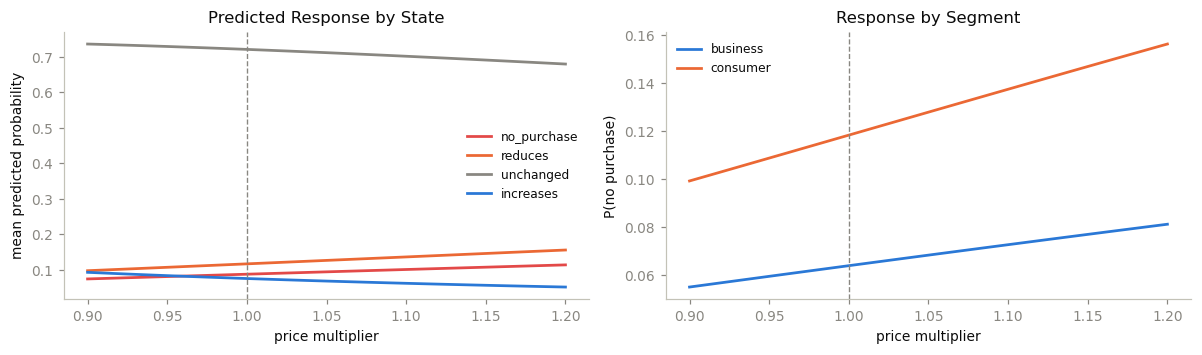

P(no purchase) swing across the range: business +0.0262, consumer +0.0572
Consumer should swing wider. If it does not, the selective-increase premise fails.
Observed no-purchase rate by segment and price (all trips)


,0.90,0.95,1.00,1.10,1.20
consumer,0.103,0.111,0.118,0.163,0.214
business,0.068,0.066,0.067,0.082,0.090


In [13]:
# Sweep Price Range
GRID = np.round(np.linspace(0.90, 1.20, 25), 4)  # 25 points, 1.25pp apart, endpoints included exactly
SWEEP_SIGN = {'no_purchase': +1, 'reduces': +1, 'unchanged': -1, 'increases': -1}

sweep = pd.DataFrame(
    [dict(zip(CLASSES, raw_score(X[te], trips[te], m).mean(axis = 0)), price_multiplier = m) for m in GRID]
).set_index('price_multiplier')

display(sweep.iloc[::4].round(4).rename_axis(None))

viol = {c: int(((sweep[c].diff().dropna()) * SWEEP_SIGN[c] < -1e-9).sum()) for c in CLASSES}
flat = {c: int((sweep[c].diff().abs().dropna() < 1e-9).sum()) for c in CLASSES}
print(f'\nMonotonicity violations : {viol}')
print(f'Flat steps (staircase)  : {flat}')

i_np = IDX['no_purchase']
fig, axes = plt.subplots(1, 2, figsize = (11, 3.3))
for c, col in zip(CLASSES, [RED, ACCENT2, MUTED, ACCENT]):
    axes[0].plot(sweep.index, sweep[c], label = c, color = col, linewidth = 1.8)
    
axes[0].axvline(1.0, color = MUTED, linestyle = '--', linewidth = 0.9)
axes[0].set_xlabel('price multiplier')
axes[0].set_ylabel('mean predicted probability')
axes[0].set_title('Predicted Response by State')
axes[0].legend(frameon = False, fontsize = 8)

spans = {}
for seg, lbl, col in [(1, 'business', ACCENT), (0, 'consumer', ACCENT2)]:
    m = trips[te]['is_business'].to_numpy().astype(int) == seg
    curve = [raw_score(X[te][m], trips[te][m], p)[:, i_np].mean() for p in GRID]
    spans[lbl] = curve[-1] - curve[0]
    axes[1].plot(GRID, curve, color = col, linewidth = 1.8, label = lbl)
    
axes[1].axvline(1.0, color = MUTED, linestyle = '--', linewidth = 0.9)
axes[1].set_xlabel('price multiplier')
axes[1].set_ylabel('P(no purchase)')
axes[1].set_title('Response by Segment')
axes[1].legend(frameon = False, fontsize = 8)
plt.tight_layout()
plt.show()

print(
    f"P(no purchase) swing across the range: business {spans['business']:+.4f}, "
    f"consumer {spans['consumer']:+.4f}"
)

print('Consumer should swing wider. If it does not, the selective-increase premise fails.')

# The raw data's own answer, for comparison
raw_cmp = (
    trips.assign(np_flag = (trips.y == 'no_purchase').astype(float))
        .pivot_table(index = 'is_business', columns = 'price_multiplier', values = 'np_flag')
)

raw_cmp.index = raw_cmp.index.map({False: 'consumer', True: 'business'})
print('Observed no-purchase rate by segment and price (all trips)')
display(raw_cmp.round(3).rename_axis(None).rename_axis(None, axis = 1))


### 6.2 Regional Price Holdout: the Gate

**Purpose:** Tests whether a price effect estimated on part of the book applies to the rest of it: the assumption the whole simulation is built on.

**Design Notes:**

1. The temporal split can't validate the price response, so hold out a region instead
  - Refit both stages with all Asia-Pacific trips removed
  - Predict Asia-Pacific trips during the market test, at elevated prices the model never saw for that region
2. If the model under-predicts the response, the revenue case is optimistic
  - It understates the damage from a price rise and makes the +20% ceiling look safer than it is
  - The ratio computed below is exported so notebook 03 can bracket the simulation rather than pretend the miss isn't there

**Observations:**

1. Predicted vs. observed no-purchase rate diverges at both held-out price levels (e.g. 1.20x: 9.83% predicted vs. 12.65% observed)
2. Response slope: observed / predicted = 1.49x; the model under-states the out-of-region response
3. Notebook 03 is directed to run the simulation scaled by 1.0 and by 1.49 to bracket the answer


In [14]:
# Regional Holdout
is_asia_pacific = trips['region'].isin(['asia', 'oceania']).to_numpy()
h_tr = tr & ~is_asia_pacific
h_s1 = h_tr & (trips['price_multiplier'] == 1.0).to_numpy()
h_te = is_asia_pacific & trips['month'].between(8, 15).to_numpy()

g_h = HistGradientBoostingClassifier(
    max_iter = 400, learning_rate = 0.06, max_leaf_nodes = 31,
    min_samples_leaf = 40, l2_regularization = 1.0,
    early_stopping = True, validation_fraction = 0.15,
    random_state = 0
).fit(X[h_s1], y[h_s1])

ord_h = [list(g_h.classes_).index(c) for c in CLASSES]

def s1_h(Xf):
    P = np.clip(g_h.predict_proba(Xf)[:, ord_h], 1e-6, None)
    return P / P.sum(axis = 1, keepdims = True)

res_h = minimize(
    nll, np.zeros(9),
    args = (np.log(s1_h(X[h_tr])), price_design(trips[h_tr]), yi[h_tr]),
    method = 'L-BFGS-B', bounds = bounds, options = {'maxiter': 500}
)

B_h = res_h.x.reshape(len(FIT_CLASSES), len(TERMS))

eta_h = np.log(s1_h(X[h_te]))
Z_h = price_design(trips[h_te])

for k, c in enumerate(FIT_CLASSES):
    eta_h[:, IDX[c]] += Z_h @ B_h[k]
    
P_h = softmax(eta_h)

cmp = (
    pd.DataFrame({
        'price': trips.loc[h_te, 'price_multiplier'].to_numpy(),
        'predicted': P_h[:, i_np],
        'observed': (y[h_te] == 'no_purchase').astype(float)
    }).groupby('price').agg(trips = ('observed', 'size'),
    predicted = ('predicted', 'mean'),
    observed = ('observed', 'mean')).round(4)
)

cmp['error'] = (cmp['predicted'] - cmp['observed']).round(4)
print('Asia-Pacific during the market test, predicted by a model that never saw Asia-Pacific')
display(cmp.rename_axis(None))

if len(cmp) >= 2:
    pred_slope = cmp['predicted'].iloc[-1] - cmp['predicted'].iloc[0]
    obs_slope = cmp['observed'].iloc[-1] - cmp['observed'].iloc[0]
    RESPONSE_RATIO = float(obs_slope / pred_slope) if abs(pred_slope) > 1e-9 else np.nan
    print(f'\nResponse slope across the held-out price levels')
    print(f'  predicted {pred_slope:+.4f}   observed {obs_slope:+.4f}')
    print(f'  observed / predicted = {RESPONSE_RATIO:.2f}x')
    if RESPONSE_RATIO > 1.25:
        print('\n  The model UNDER-states the price response out of region. The revenue')
        print('  case built on it is optimistic. Notebook 03 must run the price response')
        print(f'  scaled by 1.0 and by {RESPONSE_RATIO:.2f} to bracket the answer.')
    elif RESPONSE_RATIO < 0.8:
        print('\n  The model OVER-states the response out of region; the case is')
        print('  conservative. Bracket it the same way.')
    else:
        print('\n  The response transfers. Applying one price to the whole book is justified.')
else:
    RESPONSE_RATIO = np.nan
    print('\nToo few held-out price levels to estimate a slope.')
    

Asia-Pacific during the market test, predicted by a model that never saw Asia-Pacific


,trips,predicted,observed,error
1.1,2687,0.0878,0.1109,-0.0231
1.2,2759,0.0983,0.1265,-0.0282



Response slope across the held-out price levels
  predicted +0.0105   observed +0.0156
  observed / predicted = 1.49x

  The model UNDER-states the price response out of region. The revenue
  case built on it is optimistic. Notebook 03 must run the price response
  scaled by 1.0 and by 1.49 to bracket the answer.


---
## 7 · Calibration

**Purpose:** Corrects the raw probabilities so they're numerically right, not just well-ranked, since the simulation consumes them as quantities.

**Design Notes:**

1. Isotonic regression, fit per class on the calib window (months 16-19)
2. The decision to calibrate at all is made without touching test
  - 70% of calib fits a decision-only isotonic; the remaining 30% scores raw vs. isotonic to decide (§8)
  - The production calibrator is then refit on the full calib window
  - Test (20-23) is reserved purely for reporting, never for that decision

**Observations:**

1. Isotonic improves Brier score for 3 of 4 classes on the held-out decision slice
2. On test, isotonic brings mean predicted rates much closer to observed (e.g. unchanged 0.7205 raw vs. 0.7303 isotonic vs. 0.7301 observed)
3. Brier improvements on test are small but consistent with the decision-slice result, confirming the choice generalizes


Calibration decision: held-out 30% of the calib window (not test)


,raw,isotonic
no_purchase,0.08154,0.08154
reduces,0.08937,0.08929
unchanged,0.18925,0.18882
increases,0.06283,0.06259


Brier score by class on TEST: reporting only, not used for the USE_CAL decision above


,raw,isotonic
no_purchase,0.08454,0.08451
reduces,0.09606,0.09633
unchanged,0.19533,0.19527
increases,0.06257,0.06231


Mean predicted vs observed rate


,observed,raw,isotonic
no_purchase,0.0941,0.0876,0.0924
reduces,0.1091,0.1170,0.1099
unchanged,0.7301,0.7205,0.7303
increases,0.0667,0.0749,0.0673


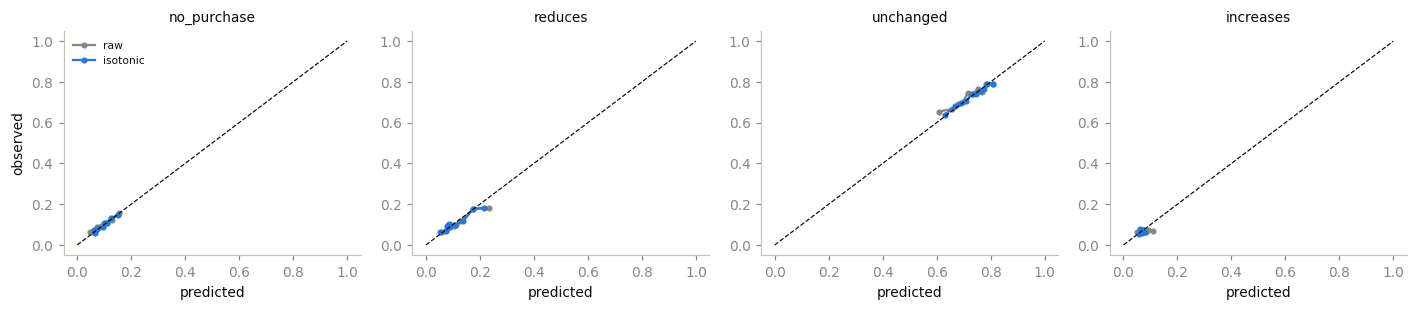

Caution: isotonic is fitted at observed prices. Applying it to a counterfactual
price assumes the correction does not itself depend on price: defensible over a
30-point range, and §6.2 is the check on the underlying response.


In [15]:
# Calibrate Probabilities
def brier_by_class(P, yv):
    return pd.Series({c: brier_score_loss((yv == c).astype(int), P[:, i])
                      for i, c in enumerate(CLASSES)})


def _calibrate_with(cals, P):
    Q = np.clip(np.column_stack([cals[c].predict(P[:, i]) for i, c in enumerate(CLASSES)]),
                1e-6, 1 - 1e-6)
    return Q / Q.sum(axis=1, keepdims=True)


# Decide WHETHER to calibrate on a held-out slice of calib, never on test
calib_rng = np.random.default_rng(0)
ca_pos = np.where(ca)[0]
perm = calib_rng.permutation(len(ca_pos))
n_fit = int(0.7 * len(ca_pos))
ca_fit, ca_eval = np.zeros_like(ca), np.zeros_like(ca)
ca_fit[ca_pos[perm[:n_fit]]] = True
ca_eval[ca_pos[perm[n_fit:]]] = True

CALS_decision = {c: IsotonicRegression(out_of_bounds='clip').fit(
                     raw_score(X[ca_fit], trips[ca_fit])[:, i], (y[ca_fit] == c).astype(int))
                 for i, c in enumerate(CLASSES)}
P_ca_eval = raw_score(X[ca_eval], trips[ca_eval])
decision_score = pd.DataFrame({
    'raw': brier_by_class(P_ca_eval, y[ca_eval]),
    'isotonic': brier_by_class(_calibrate_with(CALS_decision, P_ca_eval), y[ca_eval]),
})
print('Calibration decision: held-out 30% of the calib window (not test)')
display(decision_score.round(5))

# Refit the production calibrator on the full calib window
P_ca = raw_score(X[ca], trips[ca])
CALS = {c: IsotonicRegression(out_of_bounds='clip').fit(P_ca[:, i], (y[ca] == c).astype(int))
        for i, c in enumerate(CLASSES)}


def calibrate(P):
    return _calibrate_with(CALS, P)


P_te_cal = calibrate(P_te)
print('Brier score by class on TEST: reporting only, not used for the USE_CAL decision above')
display(pd.DataFrame({'raw': brier_by_class(P_te, y[te]),
                      'isotonic': brier_by_class(P_te_cal, y[te])}).round(5))

print('Mean predicted vs observed rate')
display(pd.DataFrame({'observed': [(y[te] == c).mean() for c in CLASSES],
                      'raw': P_te.mean(0), 'isotonic': P_te_cal.mean(0)},
                     index=CLASSES).round(4))

fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
for i, (c, ax) in enumerate(zip(CLASSES, axes)):
    for P, lbl, col in [(P_te, 'raw', MUTED), (P_te_cal, 'isotonic', ACCENT)]:
        try:
            frac, mp = calibration_curve((y[te] == c).astype(int), P[:, i],
                                         n_bins=10, strategy='quantile')
            ax.plot(mp, frac, marker='o', ms=3, label=lbl, color=col, linewidth=1.5)
        except ValueError:
            pass
    ax.plot([0, 1], [0, 1], color=INK, linestyle='--', linewidth=0.8)
    ax.set_title(c, fontsize=9)
    ax.set_xlabel('predicted')
    if i == 0:
        ax.set_ylabel('observed')
        ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

print('Caution: isotonic is fitted at observed prices. Applying it to a counterfactual')
print('price assumes the correction does not itself depend on price: defensible over a')
print('30-point range, and §6.2 is the check on the underlying response.')


---
## 8 · The Production Scorer

**Purpose:** Chooses between raw and calibrated probabilities for production use, and defines the single interface notebook 03 calls.

**Design Notes:**

1. The choice was already made in §7, on a held-out slice of calib, before test was scored
2. score_trips(Xf, df, mult, response_scale) is the interface
  - mult re-prices the book
  - response_scale stretches the price response, for §6.2's bracketing

**Observations:**

1. Isotonic wins on every metric except mean AUC (which calibration doesn't affect by construction)
2. Aggregate probability error drops from 3.2% (raw) to 0.3% (isotonic)
3. Calibration is used in production
4. Scoring the test set at three prices confirms a smooth, monotone shift in every class's probability


In [16]:
# Choose Production Scorer
cand = {'raw': P_te, 'isotonic': P_te_cal}
score = pd.DataFrame({
    k: {
        'log loss': LL(y[te], P),
        'mean Brier': brier_by_class(P, y[te]).mean(),
        'aggregate prob error': np.abs(P.mean(0) - np.array([(y[te] == c).mean() for c in CLASSES])).sum(),
        'mean AUC': np.mean(
            [roc_auc_score((y[te] == c).astype(int), P[:, i])
            for i, c in enumerate(CLASSES)]
        )
       }
    
    for k, P in cand.items()}).T.round(5)

print('Test-set metrics: reporting only. USE_CAL below was decided in §7 on a')
print('held-out slice of the calib window, before test was ever scored.')
display(score)
print(f'base-rate log loss benchmark: {BASE_LL:.4f}')

USE_CAL = bool(decision_score['isotonic'].mean() <= decision_score['raw'].mean())
print(f'Using calibration: {USE_CAL}')


def score_trips(Xf, df, mult = None, response_scale = 1.0):
    '''Production interface. `mult` re-prices the book; `response_scale` stretches
    the price response, for the §6.2 bracketing that notebook 03 needs.'''
    eta = np.log(stage1_proba(Xf))
    Z = price_design(df, mult)
    for k, c in enumerate(FIT_CLASSES):
        eta[:, IDX[c]] += response_scale * (Z @ B[k])
    P = softmax(eta)
    return calibrate(P) if USE_CAL else P


print('\nSanity: the test set at three prices')
for m in [0.90, 1.00, 1.20]:
    p = score_trips(X[te], trips[te], m).mean(0)
    print(f'  x{m:.2f}  ' + '  '.join(f'{c} = {v:.4f}' for c, v in zip(CLASSES, p)))
    

Test-set metrics: reporting only. USE_CAL below was decided in §7 on a
held-out slice of the calib window, before test was ever scored.


,log loss,mean Brier,aggregate prob error,mean AUC
raw,0.86604,0.10963,0.03199,0.56632
isotonic,0.86573,0.10960,0.00330,0.56572


base-rate log loss benchmark: 0.8792
Using calibration: True

Sanity: the test set at three prices
  x0.90  no_purchase = 0.0830  reduces = 0.0914  unchanged = 0.7517  increases = 0.0739
  x1.00  no_purchase = 0.0923  reduces = 0.1090  unchanged = 0.7312  increases = 0.0675
  x1.20  no_purchase = 0.1104  reduces = 0.1687  unchanged = 0.6702  increases = 0.0506


---
## 9 · Export

**Purpose:** Writes the scored trips, per-account price response, and model metadata that notebooks 02-04 load.

**Design Notes:**

1. Parquet preferred (smaller, keeps dtypes); falls back to CSV if pyarrow/fastparquet are not installed
2. response_ratio (§6.2) travels with the export, so notebook 03 can bracket the simulation rather than assume the bias away

In [17]:
# Export results
P_all = score_trips(X, trips)
scored = trips[[
    'trip_id', 'account_id', 'month', 'region', 'is_business',
    'lines_traveling', 'days_traveled', 'price_multiplier', 'y'
]].copy()

for i, c in enumerate(CLASSES):
    scored[f'p_{c}'] = P_all[:, i]

scored['slice'] = np.select([tr, ca, te], ['train', 'calib', 'test'], default='?')

# Per-account price response: what notebook 04 clusters on
curves = {f'p_np_{m:.2f}': score_trips(X, trips, m)[:, i_np] for m in [0.90, 1.00, 1.10, 1.20]}
resp = pd.DataFrame({'account_id': trips['account_id'].to_numpy(), **curves}) \
    .groupby('account_id').mean().reset_index()
resp['response_span'] = resp['p_np_1.20'] - resp['p_np_0.90']

meta = pd.DataFrame({
    'key': ['day_thresh', 'use_calibration', 'response_ratio', 'base_log_loss', 'test_log_loss'],
    'value': [DAY_THRESH, int(USE_CAL), RESPONSE_RATIO, BASE_LL, LL(y[te], P_te_cal if USE_CAL else P_te)],
})
display(meta.set_index('key').rename_axis(None))

display(save_tables({
    'scored_trips': scored,
    'account_price_response': resp,
    'price_sweep': sweep.reset_index(),
    'model_meta': meta,
}))

,value
day_thresh,0.700000
use_calibration,1.000000
response_ratio,1.485714
base_log_loss,0.879191
test_log_loss,0.865726


,rows
scored_trips.parquet,94579
account_price_response.parquet,29406
price_sweep.parquet,25
model_meta.parquet,5


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Price effect survives controls | §4 | The response is real, not composition |
| Trees discriminate between accounts | §5 | AUC above 0.5 per class, increases excepted by design |
| Stage-2 coefficients match §4 | §6 | Stage 2 is measuring price, not absorbing something else |
| Net sign correct on every row | §6 | Not just the base coefficient: the effect each trip actually faces |
| Smooth, monotone price curve | §6.1 | Simulation curves will be defensible |
| Response transfer measured | §6.2 | Quantified as a ratio, exported to bracket the simulation |
| Probabilities calibrated | §7–8 | Expected-revenue arithmetic is sound |

### Carry into notebook 03

1. **score_trips(X, df, mult, response_scale)** is the interface. Pass a scalar mult to re-price the book.
2. **Bracket with response_scale.** If §6.2 found the response under-stated, run the simulation at 1.0 and at the measured ratio and report both. An unbracketed answer overstates the safety of a price rise.
3. **Draw the macro shock once per iteration**, applied to every account. Independent draws understate the spread and report confidence the analysis has not earned.
4. **Expect the +20% cap to bind.** The panel is net inelastic across the range, so revenue is still climbing at the ceiling. Say plainly that the constraint chose +20%, not the model.

### Next

02_magnitude_model.ipynb: conditional day and line counts for reduces and increases, fitted only on trips in those states, so expected revenue has a size to multiply by and not just a direction.

---


# 02 · The Magnitude Model

**Purpose.** Notebook 01 predicts *which* state a trip lands in. Three of the four states carry a determined revenue outcome once the state is known:

| State | Revenue |
|---|---|
| no_purchase | zero |
| unchanged | full coverage: every travelling line, every travelled day |
| reduces | **unknown: needs a size** |
| increases | **unknown: needs a size** |

A trip that reduces from ten days to nine and one that reduces from ten to two are the same state and nowhere near the same money. This notebook supplies the size, so notebook 03 can compute

$$\mathbb{E}[\text{revenue}] = \sum_{\text{state}} P(\text{state}) \times \text{revenue}(\text{state})$$

with a real number in every term.

**Two models, fitted only on trips in the relevant state**

| Model | Target | Form |
|---|---|---|
| Reduction depth | days bought / days travelled, and lines active / lines travelling | Binomial proportion, weighted by trip length |
| Increase size | extra days bought beyond days travelled | Positive count |

**Same architecture as notebook 01, for the same reason.**

1. Non-price features go to gradient-boosted trees fitted on standard-price trips only; price enters as a sign-constrained parametric term on top
2. Magnitude must respond to price (a bigger increase should produce a deeper cut, not merely more cutters), and that response has to be smooth and correctly signed everywhere

**One contamination to keep in view throughout.** The labels are reconstructed, not observed. The data notebook measured the reduces rule at roughly 0.72 precision, so about a quarter of the trips this model trains on are incidental one-day shortfalls rather than deliberate reductions. They are shallow by construction and pull the fitted depth toward zero. §5 sizes that bias rather than assuming it away.

In [18]:
# Load inputs
trips = load_trips()

# Shared price grid for the section's revenue-curve and export cells
GRID = np.round(np.linspace(0.90, 1.20, 13), 4)

print(f'{len(trips):,} trips loaded')

94,579 trips loaded


---
## 1 · Labels, Features and the Split

**Purpose:** Rebuilds notebook 01's labels, features, and split exactly, so the state and magnitude models describe the same population.

**Design Notes:**

1. Identical to notebook 01 by design: label rule, leakage exclusions, expanding-window history, and temporal split all carry over unchanged
  - If they differed, the state probabilities and the magnitudes would describe different populations

**Observations:**

1. Reconstructed labels: unchanged 68,763, reduces 10,724, no_purchase 8,972, increases 6,120
2. reduces: 8,709 train / 2,015 test; increases: 4,887 train / 1,233 test, enough in both slices to fit and validate


In [19]:
# Rebuild labels, features, split
trips['y'] = reconstruct_label(trips)
trips['log_price'] = np.log(trips['price_multiplier'])
trips['prior_trips'] = prior_trip_count(trips)

X = build_features(trips)
X['prior_trips'] = trips['prior_trips']

month = trips['month'].to_numpy()
tr, te = month <= 19, month >= 20            # no calibration slice needed here
STD = (trips['price_multiplier'] == 1.0).to_numpy()

display(trips['y'].value_counts().to_frame('count').rename_axis(None))
display(pd.DataFrame({
    'train': [((trips.y == 'reduces') & tr).sum(), ((trips.y == 'increases') & tr).sum()],
    'test': [((trips.y == 'reduces') & te).sum(), ((trips.y == 'increases') & te).sum()],
}, index=['reduces', 'increases']))

,count
unchanged,68763
reduces,10724
no_purchase,8972
increases,6120


,train,test
reduces,8709,2015
increases,4887,1233


---
## 2 · What Reduction Actually Looks Like

**Purpose:** Looks at the shape of what's being modelled before fitting anything, since the shape decides the model form.

**Design Notes:**

1. Is depth continuous or clustered?
  - If reductions pile up at one or two specific coverage levels, a conditional mean is the wrong summary
2. Does depth move with price, or only frequency?
  - The substantive question: if a price rise makes more people cut but doesn't make the cuts deeper, the revenue arithmetic is far simpler and the magnitude model matters much less
3. Chart: frequency and depth sit on different scales, shown as two stacked panels rather than one dual-axis chart, which would imply a false alignment

**Observations:**

1. Reduction depth: median coverage 0.50, ranging 0.06 to 1.00; continuous, not clustered at one or two levels
2. Increase size: median 1 extra day, 2 at the 90th percentile and 6 at the maximum, a right-skewed count
3. Both frequency and depth move with price: reduce rate rises from 7.9% to 16.5%, and mean coverage when reducing falls from 0.572 to 0.391, across the tested range
4. 7.2% of reducing trips also cut lines, not just days


Reduction depth


,value
count,10724.000
mean,0.498
std,0.156
min,0.056
10%,0.263
25%,0.333
50%,0.500
75%,0.667
90%,0.667
max,1.000


Lines also cut: 7.2% of reducing trips
Increase size (extra days)


,value
count,6120.00
mean,1.21
std,0.57
min,1.00
25%,1.00
50%,1.00
75%,1.00
90%,2.00
max,6.00


Depth by price: does a higher price cut deeper, or just cut more often?


,trips,reduce_rate,mean_coverage_when_reducing,mean_days_short
0.90,6722,0.0785,0.572,2.23
0.95,8045,0.0988,0.544,2.26
1.00,63248,0.1094,0.514,2.54
1.10,10065,0.1398,0.448,3.09
1.20,6499,0.1649,0.391,3.44


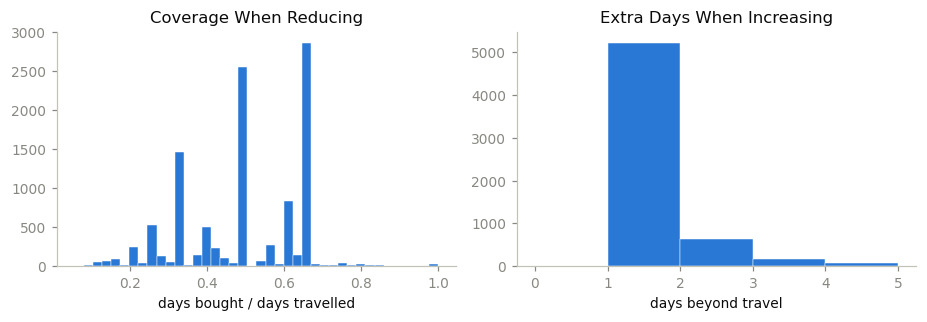

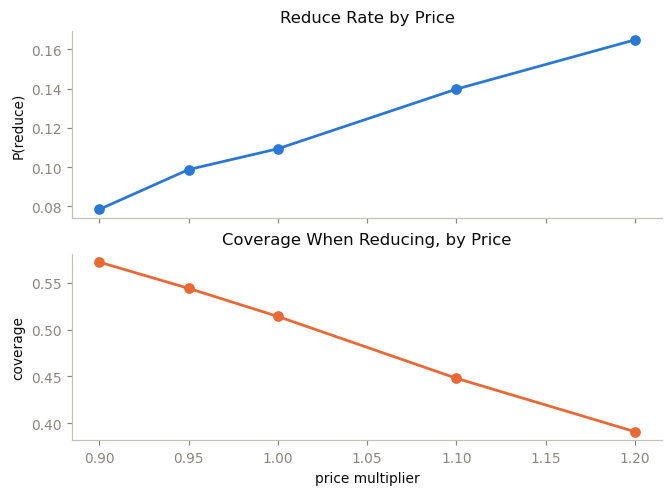

Both should move with price. If only the rate moves, the magnitude model
is a formality; if coverage falls too, the two effects compound.


In [20]:
# Examine Reduction Shape
red = trips[trips.y == 'reduces'].copy()
red['day_cov'] = red['days_bought'] / red['days_traveled']
red['line_cov'] = red['lines_active'] / red['lines_traveling'].clip(lower=1)
red['days_short'] = red['days_traveled'] - red['days_bought']

inc = trips[trips.y == 'increases'].copy()
inc['extra_days'] = inc['days_bought'] - inc['days_traveled']

print('Reduction depth')
display(red['day_cov'].describe(percentiles=[.1, .25, .5, .75, .9]).round(3).to_frame('value'))
print(f'Lines also cut: {(red.line_cov < 0.999).mean():.1%} of reducing trips')

print('Increase size (extra days)')
display(inc['extra_days'].describe(percentiles=[.25, .5, .75, .9]).round(2).to_frame('value'))

print('Depth by price: does a higher price cut deeper, or just cut more often?')
depth = trips.assign(is_red=(trips.y == 'reduces')).groupby('price_multiplier').agg(
    trips=('trip_id', 'size'), reduce_rate=('is_red', 'mean')).round(4)
depth['mean_coverage_when_reducing'] = red.groupby('price_multiplier')['day_cov'].mean().round(3)
depth['mean_days_short'] = red.groupby('price_multiplier')['days_short'].mean().round(2)
display(depth.rename_axis(None))

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3))
axes[0].hist(red['day_cov'], bins=40, color=ACCENT, edgecolor=SURFACE, linewidth=0.3)
axes[0].set_title('Coverage When Reducing')
axes[0].set_xlabel('days bought / days travelled')

axes[1].hist(inc['extra_days'], bins=range(0, int(inc.extra_days.quantile(0.99)) + 2),
             color=ACCENT, edgecolor=SURFACE, linewidth=0.3)
axes[1].set_title('Extra Days When Increasing')
axes[1].set_xlabel('days beyond travel')
plt.tight_layout()
plt.show()

# Two stacked panels, not dual-axis (see Design Notes)
fig, axes = plt.subplots(2, 1, figsize=(6, 4.4), sharex=True, layout='constrained')
axes[0].plot(depth.index, depth['reduce_rate'], marker='o', color=ACCENT, linewidth=1.8)
axes[0].set_ylabel('P(reduce)')
axes[0].set_title('Reduce Rate by Price')

axes[1].plot(depth.index, depth['mean_coverage_when_reducing'], marker='o', color=ACCENT2, linewidth=1.8)
axes[1].set_xlabel('price multiplier')
axes[1].set_ylabel('coverage')
axes[1].set_title('Coverage When Reducing, by Price')
plt.show()

print('Both should move with price. If only the rate moves, the magnitude model')
print('is a formality; if coverage falls too, the two effects compound.')


---
## 3 · Reduction Depth

**Purpose:** Models how deep a reduction goes (days bought as a share of days travelled), not just whether one happens.

**Design Notes:**

1. Modelled as a binomial proportion: of the days available, how many get bought
  - Weighted by trip length, since a ten-day trip carries ten times the revenue information of a one-day trip
  - Tree stage fits the logit-transformed, exposure-weighted target under squared-error loss (an approximation, not a true binomial deviance fit); the parametric price term on top is a genuine weighted Bernoulli log-likelihood
2. Two components, since a household can cut days, cut lines, or both
  - Day coverage: days_bought / days_traveled
  - Line coverage: lines_active / lines_traveling
3. Same architecture as notebook 01: trees on non-price features fitted on standard-price trips only, then a parametric price term
  - Fitting the trees on all prices would let them learn the price effect through region and month, the same contamination notebook 01 fixed

**Observations:**

1. Day-coverage price coefficient -2.98 (business interaction +0.52); line-coverage coefficient hits its bound at -1.5, flagged as not identified: only 7.2% of reducing trips cut lines at all
2. Zero wrong-signed net effects on either channel
3. Held-out MAE (0.121) beats the constant baseline (0.122)
4. Predicted coverage falls smoothly and monotonically from 0.58 to 0.40 across the tested range, with zero monotonicity violations


In [21]:
# Fit Reduction Depth
def logit(p):
    p = np.clip(p, 1e-4, 1 - 1e-4)
    return np.log(p / (1 - p))


def expit(z):
    return 1.0 / (1.0 + np.exp(-z))


BOUND = -5.0      # a coefficient at the wall means unidentified, not strong


def fit_coverage(target_col, denom_col, label, bound=None):
    '''Trees on non-price features (standard price only), then a price term.'''
    m_red = (trips.y == 'reduces').to_numpy()
    fit_rows = m_red & tr & STD
    n = trips[denom_col].to_numpy().clip(1)
    cov = (trips[target_col].to_numpy() / n)

    base = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15, min_samples_leaf=40,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15,
        random_state=0,
    ).fit(X[fit_rows], logit(cov[fit_rows]), sample_weight=n[fit_rows])

    # Parametric price term: higher price -> lower coverage, enforced by a bound.
    rows = m_red & tr
    z0 = base.predict(X[rows])
    lp = trips.loc[rows, 'log_price'].to_numpy()
    biz = trips.loc[rows, 'is_business'].to_numpy().astype(float)
    obs = cov[rows]
    wt = n[rows]

    def loss(th):
        z = z0 + th[0] * lp + th[1] * lp * biz
        p = expit(z)
        return -np.sum(wt * (obs * np.log(np.clip(p, 1e-9, 1)) +
                             (1 - obs) * np.log(np.clip(1 - p, 1e-9, 1)))) / wt.sum()

    lo = BOUND if bound is None else bound
    r = minimize(loss, np.zeros(2), method='L-BFGS-B',
                 bounds=[(lo, 0), (-4, 4)], options={'maxiter': 400})
    theta = r.x
    if abs(theta[0] - lo) < 1e-6:
        print(f'  WARNING: price coefficient pinned at the bound ({lo}). The')
        print('  parameter is not identified: too few trips move this channel.')

    net = theta[0] + theta[1] * biz
    refit = (net > 0).mean() > 0.01
    if refit:
        print(f'{label}: initial fit had {((net > 0).mean()):.2%} wrong-signed net effect:')
        print('  refitting without the interaction to guarantee the sign')
        r = minimize(loss, np.zeros(2), method='L-BFGS-B',
                     bounds=[(lo, 0), (0, 0)], options={'maxiter': 400})
        theta = r.x
        net = theta[0] + theta[1] * biz

    # Print after any refit, so diagnostics always match the theta returned
    print(f'{label}: price coefficient {theta[0]:+.3f}, business interaction {theta[1]:+.3f}'
          f"{'  (refit, no interaction)' if refit else ''}")
    print(f'  net effect min/median/max {net.min():+.3f} / {np.median(net):+.3f} / {net.max():+.3f}'
          f'   wrong sign: {(net > 0).mean():.2%}')
    return base, theta


print('Fitting reduction depth')
day_base, day_theta = fit_coverage('days_bought', 'days_traveled', 'day coverage ')
# Tight bound: only a minority of trips cut lines, so this channel is thin
line_share = ((trips.y == 'reduces') &
              (trips.lines_active < trips.lines_traveling)).sum() / max((trips.y == 'reduces').sum(), 1)
print(f'line cuts occur on {line_share:.1%} of reducing trips')
line_base, line_theta = fit_coverage('lines_active', 'lines_traveling', 'line coverage',
                                     bound=-1.5)


def predict_coverage(base, theta, Xf, df, mult=None):
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df['log_price'].to_numpy()
    z = base.predict(Xf) + theta[0] * lp + theta[1] * lp * df['is_business'].to_numpy().astype(float)
    return np.clip(expit(z), 0.02, 1.0)

Fitting reduction depth
day coverage : price coefficient -2.980, business interaction +0.516
  net effect min/median/max -2.980 / -2.464 / -2.464   wrong sign: 0.00%
line cuts occur on 7.2% of reducing trips
  parameter is not identified: too few trips move this channel.
line coverage: price coefficient -1.500, business interaction -4.000
  net effect min/median/max -5.500 / -5.500 / -1.500   wrong sign: 0.00%


Day coverage, held-out trips that reduced


,MAE,R2,mean predicted
model,0.1213,0.0313,0.5133
constant (train mean),0.1222,-0.0104,0.4952


observed mean coverage on test: 0.5104

The model has to beat the constant on MAE. Coverage is a narrow, noisy
quantity, so a modest R2 is expected: the aggregate mean matters more,
since that is what the revenue arithmetic consumes.

Predicted coverage at 0.90 / 1.00 / 1.20: 0.5847 / 0.5156 / 0.3966
Monotonicity violations across the range: 0


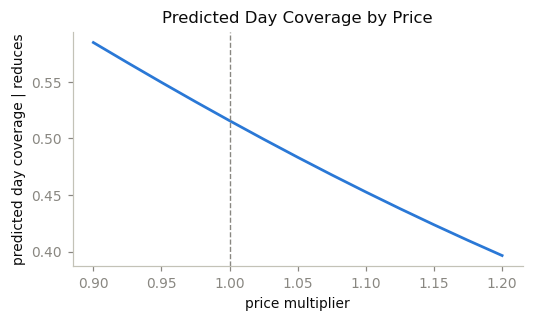

In [22]:
# Validate Depth Model
m_te = ((trips.y == 'reduces') & te).to_numpy()
df_te = trips[m_te]
obs_cov = (df_te['days_bought'] / df_te['days_traveled']).to_numpy()
pred_cov = predict_coverage(day_base, day_theta, X[m_te], df_te)

train_mean = ((trips.loc[(trips.y == 'reduces') & tr, 'days_bought'] /
               trips.loc[(trips.y == 'reduces') & tr, 'days_traveled']).mean())
const_pred = np.full_like(obs_cov, train_mean)

print('Day coverage, held-out trips that reduced')
# A train-mean constant's test-set R2 is only exactly 0 by coincidence
display(pd.DataFrame({
    'MAE': [mean_absolute_error(obs_cov, pred_cov),
            mean_absolute_error(obs_cov, const_pred)],
    'R2': [r2_score(obs_cov, pred_cov), r2_score(obs_cov, const_pred)],
    'mean predicted': [pred_cov.mean(), train_mean],
}, index=['model', 'constant (train mean)']).round(4))
print(f'observed mean coverage on test: {obs_cov.mean():.4f}')
print('\nThe model has to beat the constant on MAE. Coverage is a narrow, noisy')
print('quantity, so a modest R2 is expected: the aggregate mean matters more,')
print('since that is what the revenue arithmetic consumes.')

# GRID defined once in imports, reused in §7/§8
curve = [predict_coverage(day_base, day_theta, X[m_te], df_te, m).mean() for m in GRID]
viol = int((np.diff(curve) > 1e-9).sum())
print(f'\nPredicted coverage at 0.90 / 1.00 / 1.20: '
      f'{curve[0]:.4f} / {curve[len(curve)//3]:.4f} / {curve[-1]:.4f}')
print(f'Monotonicity violations across the range: {viol}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(GRID, curve, color=ACCENT, linewidth=1.8)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.set_xlabel('price multiplier')
ax.set_ylabel('predicted day coverage | reduces')
ax.set_title('Predicted Day Coverage by Price')
plt.tight_layout()
plt.show()

---
## 4 · Increase Size

**Purpose:** Models how many extra days an increasing trip buys beyond what it travelled.

**Design Notes:**

1. Modelled on the log scale and exponentiated back: a positive count with a floor of one
2. Price term carries the opposite sign from reductions: a deeper discount buys more extra days
3. Increases aren't confined to discounted trips
  - Some accounts buy beyond their travel days at any price, for convenience or unplanned extensions
  - Most volume sits at the standard rate, so the price term is estimated off a thin slice at the edges of the range and should be read as weak
  - A coefficient of zero would be a real finding about this population, not a broken fit

**Observations:**

1. 30.0% of increases occur away from the standard rate: the slice the price term is estimated from
2. Price coefficient -2.429 on log extra days: a deeper discount buys more days, as expected
3. Held-out MAE (0.112) beats the constant baseline (0.287) by a wide margin
4. Mean predicted extra days (1.04) close to observed (1.09)


In [23]:
# Fit Increase Size
m_inc = (trips.y == 'increases').to_numpy()
extra = (trips['days_bought'] - trips['days_traveled']).to_numpy().astype(float)

print('Price levels at which increases occur')
display(trips.loc[m_inc, 'price_multiplier'].value_counts().sort_index().to_frame('count').rename_axis(None))
off_std = trips.loc[m_inc, 'price_multiplier'].ne(1.0).mean()
print(f'{off_std:.1%} of increases occur away from the standard rate: the price term')
print('is estimated off that slice, so treat it as weakly identified.')

fit_rows = m_inc & tr & STD
if fit_rows.sum() < 50:
    # No increases at the standard rate: fall back to all training increases and say so.
    fit_rows = m_inc & tr
    print('\nToo few increases at the standard rate; the tree is fitted on all')
    print('training increases. Price and baseline are less cleanly separated here.')

inc_base = HistGradientBoostingRegressor(
    max_iter=200, learning_rate=0.06, max_leaf_nodes=15, min_samples_leaf=30,
    l2_regularization=1.0, early_stopping=True, validation_fraction=0.15, random_state=0,
).fit(X[fit_rows], np.log(np.clip(extra[fit_rows], 1, None)))

rows = m_inc & tr
z0 = inc_base.predict(X[rows])
lp = trips.loc[rows, 'log_price'].to_numpy()
obs = np.log(np.clip(extra[rows], 1, None))


def inc_loss(th):
    return np.mean((obs - (z0 + th[0] * lp)) ** 2)


inc_theta = minimize(inc_loss, np.zeros(1), method='L-BFGS-B',
                     bounds=[(-15, 0)], options={'maxiter': 300}).x
print(f'price coefficient on log extra days: {inc_theta[0]:+.3f} '
      f'(negative = a deeper discount buys more days)')
if abs(inc_theta[0]) < 1e-6:
    print('Zero: increase size does not respond to price in this population.')
    print('Revenue from increases then scales with price only, not with volume.')


def predict_extra(base, theta, Xf, df, mult=None):
    '''Same convention as predict_coverage: self-contained, no closures.'''
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df['log_price'].to_numpy()
    return np.clip(np.exp(base.predict(Xf) + theta[0] * lp), 1.0, 30.0)


m_ite = m_inc & te
if m_ite.sum() > 20:
    pe = predict_extra(inc_base, inc_theta, X[m_ite], trips[m_ite])
    oe = extra[m_ite]
    print(f'Held-out increases: n={m_ite.sum():,}')
    print(f'  MAE model {mean_absolute_error(oe, pe):.3f}  vs constant '
          f'{mean_absolute_error(oe, np.full_like(oe, extra[rows].mean())):.3f}')
    print(f'  mean predicted {pe.mean():.2f}  observed {oe.mean():.2f}')
else:
    print(f'\nOnly {m_ite.sum()} increases in the test window: not enough to validate.')

Price levels at which increases occur


,count
0.90,517
0.95,611
1.00,4286
1.10,475
1.20,231


30.0% of increases occur away from the standard rate: the price term
is estimated off that slice, so treat it as weakly identified.
price coefficient on log extra days: -2.429 (negative = a deeper discount buys more days)
Held-out increases: n=1,233
  MAE model 0.112  vs constant 0.287
  mean predicted 1.04  observed 1.09


---
## 5 · Label Contamination: How Much Does It Bias the Depth?

**Purpose:** Measures how much the reconstructed-label rule's false positives bias the fitted depth, since this model trains on labelled reduces, not true reduces.

**Design Notes:**

1. The data notebook measured the reduces rule at roughly 0.72 precision
  - False positives are incidental one-day shortfalls, shallow by construction
  - Biases the fitted depth toward zero, and expected revenue toward optimistic
2. Because this is synthetic data, the bias is directly measurable
  - Compares depth among truly-reducing trips against depth among all labelled ones
  - Exported as a correction factor so notebook 03 can run the simulation with and without it
3. In production this number is unknowable, which is the argument for having built it here

**Observations:**

1. Label rule precision here: 77.6% (2,398 of 10,724 labelled trips are false positives)
2. True cuts run deeper: mean coverage 0.470 among truly-reducing trips vs. 0.498 among all labelled, and 0.594 among the false positives
3. Depth bias: 1.06x; true cuts are 6% deeper than the labelled average


In [24]:
# Measure Label Contamination
truth = trips['state'].replace({'substitutes': 'no_purchase', 'leaves': 'no_purchase'})
labelled = trips.y == 'reduces'
truly = labelled & (truth == 'reduces')
falsely = labelled & (truth != 'reduces')

cov_all = (trips.loc[labelled, 'days_bought'] / trips.loc[labelled, 'days_traveled']).mean()
cov_true = (trips.loc[truly, 'days_bought'] / trips.loc[truly, 'days_traveled']).mean()

display(pd.DataFrame({
    'trips': [labelled.sum(), truly.sum(), falsely.sum()],
    'mean coverage': [cov_all, cov_true,
                      (trips.loc[falsely, 'days_bought'] /
                       trips.loc[falsely, 'days_traveled']).mean() if falsely.sum() else np.nan],
}, index=['labelled reduces', 'truly reduces', 'false positives']).round(4))

print(f'Precision of the label rule here: {truly.sum() / max(labelled.sum(), 1):.3f}')
DEPTH_BIAS = float((1 - cov_true) / max(1 - cov_all, 1e-9))
print(f'True cuts are {DEPTH_BIAS:.2f}x deeper than the labelled average.')
print('Exported as depth_bias. Notebook 03 runs the simulation at 1.0 and at this')
print('factor; the gap between them is the cost of not observing the state directly.')

,trips,mean coverage
labelled reduces,10724,0.4981
truly reduces,8326,0.4705
false positives,2398,0.5940


Precision of the label rule here: 0.776
True cuts are 1.06x deeper than the labelled average.
Exported as depth_bias. Notebook 03 runs the simulation at 1.0 and at this
factor; the gap between them is the cost of not observing the state directly.


---
## 6 · Revenue per State

**Purpose:** Applies the pricing identity per state with the predicted magnitudes filled in, as the single interface notebook 03 calls.

**Design Notes:**

1. Pricing identity: revenue = (10 + 5 × (lines_active − 1)) × days_bought × price_multiplier
2. Filled in per state

| State | lines | days |
|---|---|---|
| no_purchase | 0 | 0 |
| unchanged | all travelling | all travelled |
| reduces | predicted line coverage | predicted day coverage |
| increases | all travelling | travelled + predicted extra |

3. revenue_by_state is the one function notebook 03 calls: one interface, not a set of loose predictions, keeps the two notebooks from drifting apart

**Observations:**

1. Mean revenue per trip at standard price: no_purchase 0.00, reduces 34.21, unchanged 67.06, increases 79.40
2. Predicted vs. actual revenue is close for unchanged (67.06 vs. 66.04) and reasonably close for reduces (34.21 vs. 30.28)
3. increases slightly under-predicts actual (79.40 vs. 81.19), within the range this check is meant to catch
4. End-to-end check on 18,472 held-out trips: expected total $1,071,901 vs. observed $1,051,766, a +1.91% error, within the few-percent target


In [25]:
# Compute Revenue by State
CLASSES = ['no_purchase', 'reduces', 'unchanged', 'increases']


def revenue_by_state(Xf, df, mult=1.0, depth_scale=1.0):
    '''Revenue each trip would produce in each state, at price `mult`.

    depth_scale > 1 deepens predicted reductions, for the §5 contamination
    bracket. Returns an (n, 4) array in CLASSES order.
    '''
    lines_t = df['lines_traveling'].to_numpy().astype(float)
    days_t = df['days_traveled'].to_numpy().astype(float)

    def rev(lines, days):
        lines = np.maximum(lines, 0)
        return np.where(lines > 0,
                        (PRICE_FIRST + PRICE_ADDL * (lines - 1)) * days * mult, 0.0)

    day_cov = predict_coverage(day_base, day_theta, Xf, df, mult)
    line_cov = predict_coverage(line_base, line_theta, Xf, df, mult)
    day_cov = np.clip(1 - depth_scale * (1 - day_cov), 0.02, 1.0)
    line_cov = np.clip(1 - depth_scale * (1 - line_cov), 0.02, 1.0)

    out = np.zeros((len(df), 4))
    out[:, CLASSES.index('no_purchase')] = 0.0
    out[:, CLASSES.index('unchanged')] = rev(lines_t, days_t)
    out[:, CLASSES.index('reduces')] = rev(np.maximum(np.round(lines_t * line_cov), 1),
                                           np.maximum(np.round(days_t * day_cov), 1))
    out[:, CLASSES.index('increases')] = rev(lines_t, days_t + predict_extra(inc_base, inc_theta, Xf, df, mult))
    return out


R = revenue_by_state(X[te], trips[te], 1.0)
print('Mean revenue per trip by state, at the standard price')

print('Against what actually happened on those trips')
act = trips[te].groupby('y')['pass_revenue'].mean().reindex(CLASSES)
display(pd.DataFrame({'predicted': pd.Series(R.mean(0), index=CLASSES),
                      'actual': act}).round(2))
print('These should be close for unchanged and reduces. A large gap on reduces')
print('means the depth model is off in a way that flows straight into the revenue.')

Mean revenue per trip by state, at the standard price
Against what actually happened on those trips


,predicted,actual
no_purchase,0.00,0.00
reduces,34.21,30.28
unchanged,67.06,66.04
increases,79.40,81.19


These should be close for unchanged and reduces. A large gap on reduces
means the depth model is off in a way that flows straight into the revenue.


In [26]:
# End-to-End Check
scored = load('scored_trips')
sc_te = scored[scored['slice'] == 'test'].set_index('trip_id')
te_ids = trips.loc[te, 'trip_id']
common = te_ids[te_ids.isin(sc_te.index)]

if len(common) > 0:
    idx = trips['trip_id'].isin(common).to_numpy() & te
    P = sc_te.loc[trips.loc[idx, 'trip_id'], [f'p_{c}' for c in CLASSES]].to_numpy()
    Rv = revenue_by_state(X[idx], trips[idx], 1.0)
    exp_rev = (P * Rv).sum(axis=1)
    obs_rev = trips.loc[idx, 'pass_revenue'].to_numpy()

    print(f'Expected vs observed revenue on {idx.sum():,} held-out trips')
    display(pd.DataFrame({
        'expected': [exp_rev.sum(), exp_rev.mean()],
        'observed': [obs_rev.sum(), obs_rev.mean()],
    }, index=['total', 'per trip']).round(2))
    print(f'error: {(exp_rev.sum() / obs_rev.sum() - 1):+.2%}')
    print('This is the number that matters: the simulation repeats this calculation')
    print('across prices, so an error here scales into every scenario.')
    REV_ERROR = float(exp_rev.sum() / obs_rev.sum() - 1)
else:
    REV_ERROR = np.nan
    print('scored_trips does not overlap the test window: re-run notebook 01.')

Expected vs observed revenue on 18,472 held-out trips


,expected,observed
total,1071901.09,1051766.00
per trip,58.03,56.94


error: +1.91%
This is the number that matters: the simulation repeats this calculation
across prices, so an error here scales into every scenario.


---
## 7 · The Revenue Curve

**Purpose:** Previews notebook 03's answer by combining state probabilities and magnitudes across the price range, without macro uncertainty or seasonality.

**Design Notes:**

1. A deterministic sketch of the shape, not the final answer
  - Uses depth_scale=1.0, the raw fitted depth before §5's contamination correction; notebook 03 compares the bracketed versions
2. Two things it should show
  - A smooth curve with no kinks
  - Whether revenue is still climbing at +20%: if so, the recommendation is bounded by the cap, not an interior optimum, and must be reported as a constraint

**Observations:**

1. Revenue-maximising price in the tested range: 1.20 (the cap)
2. Revenue is still climbing at the +20% ceiling: the constraint chose this price, not the model


,revenue,vs_standard
0.900,1010474.0,-0.0618
0.925,1027821.0,-0.0456
0.950,1044773.0,-0.0299
0.975,1061305.0,-0.0146
1.000,1076985.0,0.0000
1.025,1092947.0,0.0148
1.050,1109055.0,0.0298
1.075,1123904.0,0.0436
1.100,1136846.0,0.0556
1.125,1149132.0,0.0670


Revenue-maximising price in the tested range: 1.200
Revenue is still climbing at the +20% ceiling. The cap is binding, so the
recommendation is a bounded answer: the constraint chose +20%, not the model.


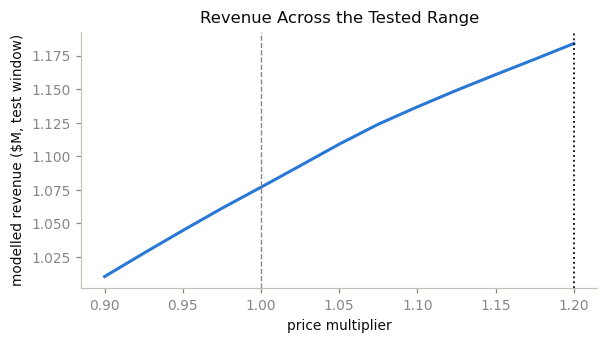

In [27]:
# Build Revenue Curve
sweep = load('price_sweep').set_index('price_multiplier')
base_rev = trips.loc[te, 'pass_revenue'].sum()

rows = []
for m in GRID:
    if float(m) in sweep.index:
        p = sweep.loc[float(m), CLASSES].to_numpy()
    else:
        j = np.argmin(np.abs(sweep.index.to_numpy() - m))
        p = sweep.iloc[j][CLASSES].to_numpy()
    Rv = revenue_by_state(X[te], trips[te], m)
    rows.append({'price_multiplier': m, 'revenue': float((Rv * p).sum(axis=1).sum())})

curve = pd.DataFrame(rows).set_index('price_multiplier')
curve['vs_standard'] = curve['revenue'] / curve.loc[1.0, 'revenue'] - 1
display(curve.round({'revenue': 0, 'vs_standard': 4}).rename_axis(None))

best = curve['revenue'].idxmax()
print(f'Revenue-maximising price in the tested range: {best:.3f}')
if best >= GRID[-1] - 1e-9:
    print('Revenue is still climbing at the +20% ceiling. The cap is binding, so the')
    print('recommendation is a bounded answer: the constraint chose +20%, not the model.')

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(curve.index, curve['revenue'] / 1e6, color=ACCENT, linewidth=2)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color=INK, linestyle=':', linewidth=1.2)
ax.set_xlabel('price multiplier')
ax.set_ylabel('modelled revenue ($M, test window)')
ax.set_title('Revenue Across the Tested Range')
plt.tight_layout()
plt.show()

---
## 8 · Export

**Purpose:** Writes the per-trip predicted magnitudes, the revenue-by-state lookup table, the deterministic revenue curve, and model metadata that notebook 03 loads.

**Design Notes:**

1. revenue_by_state is evaluated across the full price grid here and exported as a table, not called live: notebook 03 loads and pivots it
2. depth_bias (§5) and revenue_error (§6) travel with the export, so notebook 03 can bracket the simulation rather than assume the contamination away

**Observations:**

1. Four tables written: trip magnitudes, revenue by state, the deterministic revenue curve, and model metadata
2. depth_bias 1.06x, revenue reproduction error +1.9%


In [28]:
# Export results
mag = trips[['trip_id', 'account_id', 'month', 'price_multiplier']].copy()
mag['pred_day_coverage'] = predict_coverage(day_base, day_theta, X, trips)
mag['pred_line_coverage'] = predict_coverage(line_base, line_theta, X, trips)
mag['pred_extra_days'] = predict_extra(inc_base, inc_theta, X, trips)

# Revenue per state at each price on the grid: the simulation's lookup table
tbl = []
for m in GRID:
    Rv = revenue_by_state(X, trips, m)
    tbl.append(pd.DataFrame({'trip_id': trips['trip_id'].to_numpy(),
                             'price_multiplier': m,
                             **{f'rev_{c}': Rv[:, i] for i, c in enumerate(CLASSES)}}))
rev_tbl = pd.concat(tbl, ignore_index=True)

meta = pd.DataFrame({
    'key': ['depth_bias', 'revenue_error', 'day_price_coef', 'line_price_coef', 'extra_price_coef'],
    'value': [DEPTH_BIAS, REV_ERROR, float(day_theta[0]), float(line_theta[0]), float(inc_theta[0])],
})
display(meta.set_index('key').rename_axis(None))

display(save_tables({
    'trip_magnitudes': mag,
    'revenue_by_state': rev_tbl,
    'deterministic_revenue_curve': curve.reset_index(),
    'magnitude_meta': meta,
}))

,value
depth_bias,1.055014
revenue_error,0.019144
day_price_coef,-2.979781
line_price_coef,-1.500000
extra_price_coef,-2.428731


,rows
trip_magnitudes.parquet,94579
revenue_by_state.parquet,1229527
deterministic_revenue_curve.parquet,13
magnitude_meta.parquet,5


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Depth moves with price, not just frequency | §2–3 | A state-only model would understate the damage |
| Coverage model beats the constant | §3 | The magnitude carries real information |
| Depth response smooth and correctly signed | §3 | Simulation curves stay defensible |
| Increase size identified on discounts only | §4 | Stated as a limit, not hidden |
| Label contamination sized | §5 | Exported as a bracket, not assumed away |
| Expected revenue reproduces observed | §6 | The composition is arithmetically sound |
| Revenue still climbing at +20% | §7 | The cap binds: a constraint, not an optimum |

### Carry into notebook 03

1. **revenue_by_state(X, df, mult, depth_scale)** is evaluated across the full GRID here and exported as revenue_by_state.parquet in §8: notebook 03 loads that table (it does not call this function live), pivots it to rev_{state} columns per price, and combines it with notebook 01's score_trips output the same way §6's end-to-end check does: Σ P(state) × revenue(state).
2. **Bracket twice, not once.** response_scale from notebook 01 §6.2 and depth_scale from §5 here are independent sources of optimism, and both push the same direction: the unbracketed answer overstates how safe a price rise is.
3. **no_purchase is not free.** The revenue table books it at zero, which is right for the pass but wrong for the relationship. Departures carry account-level value, and notebook 03 has to subtract it using the bootstrapped rate from notebook 01 §10.

### Next

03_simulation.ipynb: 12 months forward across the price range, with the macro shock drawn once per iteration and applied to every account, so the revenue distribution has an honest width.

---


# 03 · The 12-Month Simulation

**Purpose:** Notebooks 03 and 04 answer what happens on a trip. This one answers the question leadership actually asked: over the next twelve months, at each price, how much revenue does the business make, and how wrong could that be?

1. A single expected-value calculation can't answer the second half
  - Point estimates invite a decision to be made as if the number were certain
  - Nobody could previously say how much risk a price change carried

**Three sources of uncertainty, deliberately separated**

| Source | Correlated across accounts? | Why it matters |
|---|---|---|
| Macroeconomic path | Yes | Moves how much travel happens at all |
| Market share | Yes | Moves whose travel is ours to price |
| Behavioral response | No | Each account draws its own state |

2. The correlation is the entire point
  - Drawing each account independently would let good and bad outcomes cancel across 50,000 accounts, collapsing the distribution to a spike: a precision the analysis hasn't earned
  - Macro and share draws are made once per iteration and applied to everyone, producing an honest spread
3. Two known biases, both pushing the same way
  - Notebook 01 §6.2 found the price response under-stated out of region
  - Notebook 02 §5 found reduction depth under-stated by label contamination
  - Both make a price rise look safer than it is; every scenario is run twice (as fitted, and with both corrections applied) and the recommendation is read off the conservative case
4. Scope is roaming revenue only
  - Wireless churn (customers leaving the company outright, rather than substituting the pass) was considered and excluded from this analysis: see notebook 01 §1

In [29]:
# Load inputs
trips = load_trips(with_macro=False)
macro = load('macro')
scored = load('scored_trips')
rev_tbl = load('revenue_by_state')
model_meta = load('model_meta').set_index('key')['value']
mag_meta = load('magnitude_meta').set_index('key')['value']

GRID = np.round(np.sort(rev_tbl['price_multiplier'].unique()), 4)
RESPONSE_RATIO = float(model_meta.get('response_ratio', 1.0))
DEPTH_BIAS = float(mag_meta.get('depth_bias', 1.0))

print(f'price grid: {GRID[0]:.3f} to {GRID[-1]:.3f} in {len(GRID)} steps')
print(f'response ratio (03 §6.2): {RESPONSE_RATIO:.2f}x')
print(f'depth bias     (04 §5)  : {DEPTH_BIAS:.2f}x')

price grid: 0.900 to 1.200 in 13 steps
response ratio (03 §6.2): 1.49x
depth bias     (04 §5)  : 1.06x


---
## 1 · Building the Forward Year

**Purpose:** Builds a forward 12-month trip panel, since the simulation projects next year, not the historical one.

**Design Notes:**

1. Each account's trip pattern is carried forward and re-seasonalised; the macro path is regenerated per iteration
2. Trip volume scales, trips don't get invented
  - Each historical trip carries forward with a probability set by the macro and share draws, rather than generating new synthetic trips
  - Keeps the account mix stable and confines the uncertainty to volume, where the evidence actually is
3. Seasonality is reapplied, not inherited
  - The historical window covers two years with its own macro path; reusing it would bake one realisation of the economy into every iteration

**Observations:**

1. Forward panel: 52,500 trips across 22,328 accounts
2. Months 0-11, seasonality range 0.87 to 1.15


In [30]:
# Build Forward Panel
last12 = trips[trips['month'] >= trips['month'].max() - 11].copy()
last12['fwd_month'] = last12['month'] - last12['month'].min()

# Strip the historical macro effect so it can be redrawn per iteration
hist_mult = macro.set_index('month')['travel_multiplier']
last12['hist_macro_mult'] = last12['month'].map(hist_mult).to_numpy()

# Seasonality for the forward year, macro-free
fwd_season = 1.0 + 0.15 * np.sin(2 * np.pi * (np.arange(12) - 2) / 12) \
             + 0.06 * (np.arange(12) == 11)

rev_wide = rev_tbl.pivot_table(index='trip_id', columns='price_multiplier',
                               values=[f'rev_{c}' for c in CLASSES])
prob_wide = scored.set_index('trip_id')[[f'p_{c}' for c in CLASSES]]

panel = last12[['trip_id', 'account_id', 'fwd_month', 'is_business',
                'lines_traveling', 'days_traveled']].copy()
panel = panel[panel['trip_id'].isin(prob_wide.index) & panel['trip_id'].isin(rev_wide.index)]
panel['season'] = fwd_season[panel['fwd_month'].to_numpy()]
panel['hist_macro_mult'] = last12.set_index('trip_id').loc[panel.trip_id, 'hist_macro_mult'].to_numpy()

print(f'forward panel: {len(panel):,} trips across {panel.account_id.nunique():,} accounts')
print(f'months 0-11, seasonality range {fwd_season.min():.2f} to {fwd_season.max():.2f}')

forward panel: 52,500 trips across 22,328 accounts
months 0-11, seasonality range 0.87 to 1.15


---
## 2 · The Simulation

**Purpose:** Simulates one 12-month iteration's revenue, combining macro, share, and behavioral draws with the right correlation structure.

**Design Notes:**

1. One iteration
  - Draw an AR(1) macro path for twelve months: one path, shared by every account
  - Draw a market share drift: also shared
  - For each trip, decide whether it happens (macro × share × seasonality), then draw its state from the model's probabilities at the chosen price
  - Sum pass revenue
2. Steps 1-2 are drawn once per iteration; step 3 is drawn per trip: the difference between an honest distribution and a spike
3. Antithetic pairing halves the variance for free: each macro path runs alongside its mirror image, so a strong economy and a weak one appear in equal measure rather than by luck of the draw
4. Probabilities shifted in log-probability space, not logit space
  - An earlier version's softmax(logit(p)) renormalised odds rather than probabilities, understating a 0.099 walk-away risk as 0.036
5. Forward macro path drawn from the same phi=0.85/gamma=0.55 process as the data notebook's make_macro(), not a separately-guessed pair

**Observations:**

1. Join guard passes: P(no_purchase) matches exactly between scored_trips (0.0932) and the simulation's own probability function at price 1.0
2. Sanity check across three prices confirms probability shifts move smoothly with price (0.0793 -> 0.0932 -> 0.1205)
3. Baseline (no price change), 400 iterations: median pass revenue $2,620,850
4. p5-p95: $1,970,681 to $2,995,334, a 39.1% spread relative to the median

In [31]:
# Set up simulation
N_ITER = 400

TRIP_IDS = panel['trip_id'].to_numpy()
P_BASE = np.column_stack([prob_wide.loc[TRIP_IDS, f'p_{c}'].to_numpy() for c in CLASSES])
SEASON = panel['season'].to_numpy()
HIST_M = panel['hist_macro_mult'].to_numpy()
MONTH = panel['fwd_month'].to_numpy()
N = len(panel)


def rev_at(mult, depth_scale=1.0):
    '''(n, 4) revenue per state at the nearest grid price.'''
    m = GRID[np.argmin(np.abs(GRID - mult))]
    R = np.column_stack([rev_wide[(f'rev_{c}', m)].loc[TRIP_IDS].to_numpy() for c in CLASSES])
    if depth_scale != 1.0:
        j = CLASSES.index('reduces')
        full = R[:, CLASSES.index('unchanged')]
        R = R.copy()
        R[:, j] = np.clip(full - depth_scale * (full - R[:, j]), 0, None)
    return R


# Shift each trip's own baseline log-odds by the population-level change (01 s6.1 sweep)
sweep = load('price_sweep').set_index('price_multiplier')
P_STD = P_BASE / P_BASE.sum(axis=1, keepdims=True)
SHIFT = {float(m): price_shift_logodds(sweep, m) for m in GRID}


def probs_at(mult, response_scale=1.0):
    m = float(GRID[np.argmin(np.abs(GRID - mult))])
    return apply_price_shift(P_STD, SHIFT[m], response_scale)


print('probability shift table built for', len(SHIFT), 'price points')

# Join guard: probs_at(1.0) must reproduce the scored probabilities exactly
src_mean = scored.set_index('trip_id').loc[TRIP_IDS, 'p_no_purchase'].mean()
sim_mean = probs_at(1.0)[:, 0].mean()
print(f'P(no_purchase) from scored_trips : {src_mean:.4f}')
print(f'P(no_purchase) via probs_at(1.0) : {sim_mean:.4f}')
if abs(sim_mean - src_mean) > 0.002:
    raise AssertionError(
        f'probability join is broken: {sim_mean:.4f} vs {src_mean:.4f}. '
        'Check that P_BASE columns are in CLASSES order and that TRIP_IDS '
        'aligns row-for-row with the panel.')
print('join verified')

print('Sanity: mean P(no_purchase) at three prices, response_scale=1')
display(pd.Series({f'x{m:.3f}': probs_at(m)[:, 0].mean() for m in [GRID[0], 1.0, GRID[-1]]},
                  name='P(no_purchase)').round(4).to_frame())

probability shift table built for 13 price points
P(no_purchase) from scored_trips : 0.0932
P(no_purchase) via probs_at(1.0) : 0.0932
join verified
Sanity: mean P(no_purchase) at three prices, response_scale=1


,P(no_purchase)
x0.900,0.0793
x1.000,0.0932
x1.200,0.1205


In [32]:
# Run Simulation
def simulate(mult, n_iter=N_ITER, response_scale=1.0, depth_scale=1.0,
             macro_shift=0.0, rng=None):
    '''12-month pass revenue distribution at price `mult`.

    macro_shift moves the mean of the economic path: negative = contraction.
    Returns pass_revenue per iteration.
    '''
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult, response_scale)
    R = rev_at(mult, depth_scale)
    cum = P.cumsum(axis=1)

    out = np.zeros(n_iter)
    half = n_iter // 2
    antithetic = []      # first half's draws, mirrored for the second half below

    for it in range(n_iter):
        # --- shared draws: one economy, one share path ---
        if it < half:
            shocks = rng.normal(0, 0.35, 12)
            share_d = rng.normal(0, 0.03)
            cache = (shocks, share_d)
            antithetic.append(cache)
        else:
            shocks, share_d = antithetic[it - half]
            shocks, share_d = -shocks, -share_d      # mirrored path

        # phi/gamma mirror the data notebook's make_macro() (see §2)
        idx = np.zeros(12)
        for t in range(1, 12):
            idx[t] = 0.85 * idx[t - 1] + shocks[t]
        idx = idx + macro_shift
        travel_mult = np.exp(0.55 * idx) * (1.0 + share_d)

        # --- which trips happen: shared multiplier, independent Bernoulli ---
        p_occur = np.clip(travel_mult[MONTH] * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        extra = np.maximum(p_occur - 1.0, 0)
        occurs = occurs | (rng.random(N) < np.clip(extra, 0, 1))

        # --- behavioural draw, independent per trip ---
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        pass_rev = np.where(occurs, R[np.arange(N), state], 0.0).sum()

        out[it] = pass_rev
    return out


base = simulate(1.0, rng=np.random.default_rng(1))
print(f'Baseline (no price change), {N_ITER} iterations')
display(pd.DataFrame({
    'value': [f'${np.median(base):,.0f}',
              f'${np.percentile(base, 5):,.0f} to ${np.percentile(base, 95):,.0f}',
              f'{(np.percentile(base, 95) - np.percentile(base, 5)) / np.median(base):.1%}'],
}, index=['pass revenue (median)', 'p5-p95', 'spread as % of median']))
print('A spread of a few percent would mean the correlated draws are not working.')
print('Real 12-month revenue uncertainty on a travel product is wide.')

Baseline (no price change), 400 iterations


,value
pass revenue (median),"$2,620,850"
p5-p95,"$1,970,681 to $2,995,334"
spread as % of median,39.1%


A spread of a few percent would mean the correlated draws are not working.
Real 12-month revenue uncertainty on a travel product is wide.


### 2.1 Does Correlation Actually Matter?

**Purpose:** Demonstrates, rather than asserts, that the correlated draw structure is what produces an honest spread.

**Design Notes:**

1. Re-runs the same simulation with the macro path drawn per account instead of once per iteration
  - Should produce a dramatically narrower distribution, and that narrowness would be entirely artificial
2. The diagnostic that justifies the whole structure of the notebook

**Observations:**

1. Correlated (correct): median $2.62M, coefficient of variation 0.12, p5-p95 width $1.04M
2. Independent (wrong): nearly the same median ($2.54M), but coefficient of variation collapses to 0.003 and p5-p95 width to $24,830
3. Independent draws understate the spread by 40x: the gap between an honest range and false precision


,median,coefficient of variation,p5-p95 width
correlated (correct),2.620850e+06,0.1225,1.024653e+06
independent (wrong),2.542831e+06,0.0031,2.483026e+04


Independent draws understate the spread by 40x.
That is the difference between reporting a range leadership can plan against
and reporting false precision.


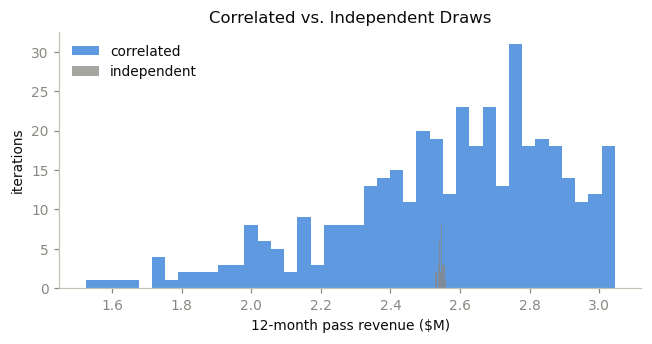

In [33]:
# Test Correlation Structure
def simulate_independent(mult, n_iter=120, rng=None):
    '''Wrong on purpose: every trip gets its own economy.'''
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult)
    R = rev_at(mult)
    cum = P.cumsum(axis=1)
    out = np.zeros(n_iter)
    for it in range(n_iter):
        idx = rng.normal(0, 0.35 / np.sqrt(1 - 0.85 ** 2), N)   # independent per trip
        travel_mult = np.exp(0.55 * idx)
        p_occur = np.clip(travel_mult * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        out[it] = np.where(occurs, R[np.arange(N), state], 0.0).sum()
    return out


indep = simulate_independent(1.0, rng=np.random.default_rng(3))
corr_sd = base.std() / base.mean()
ind_sd = indep.std() / indep.mean()

display(pd.DataFrame({
    'median': [np.median(base), np.median(indep)],
    'coefficient of variation': [corr_sd, ind_sd],
    'p5-p95 width': [np.percentile(base, 95) - np.percentile(base, 5),
                     np.percentile(indep, 95) - np.percentile(indep, 5)],
}, index=['correlated (correct)', 'independent (wrong)']).round(4))

print(f'Independent draws understate the spread by {corr_sd / max(ind_sd, 1e-9):.0f}x.')
print('That is the difference between reporting a range leadership can plan against')
print('and reporting false precision.')

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(base / 1e6, bins=40, alpha=0.75, color=ACCENT, label='correlated')
ax.hist(indep / 1e6, bins=40, alpha=0.75, color=MUTED, label='independent')
ax.set_xlabel('12-month pass revenue ($M)')
ax.set_ylabel('iterations')
ax.set_title('Correlated vs. Independent Draws')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 3 · The Price Sweep

**Purpose:** Simulates every price on the grid twice (as fitted, and conservative) so the recommendation accounts for both measured biases.

**Design Notes:**

1. Conservative case stretches the price response by notebook 01 §6.2's ratio and reduction depth by notebook 02 §5's bias
2. The gap between the two curves isn't noise
  - It's the price of two things the analysis couldn't observe directly: whether the response transfers across the book, and whether the reconstructed labels understate real reductions
3. Common random numbers: one seed shared across every price and both cases
  - A different seed per price would let the curve wander by tens of thousands of dollars on sampling noise alone, against a p5-p95 width near $1M

**Observations:**

1. As fitted: median pass revenue rises from $2.45M (0.90x) to $2.88M (1.20x)
2. Conservative: median rises from $2.48M to $2.76M, a smaller lift, as expected given both corrections push the same direction

As fitted


,p5,median,p95,lift_vs_base
0.900,1789103,2448114,2823546,-168749
0.925,1820212,2491519,2872486,-125344
0.950,1850296,2534599,2922892,-82264
0.975,1881620,2576629,2970377,-40234
1.000,1910353,2616863,3016509,0
1.025,1939697,2657935,3063683,41072
1.050,1969853,2697253,3109818,80390
1.075,1996587,2733878,3151951,117015
1.100,2018022,2761979,3184284,145116
1.125,2038596,2791105,3216279,174242


Conservative


,p5,median,p95,lift_vs_base
0.900,1808343,2475397,2856280,-133626
0.925,1834449,2510956,2895861,-98067
0.950,1859163,2545398,2934455,-63625
0.975,1882183,2577788,2973594,-31235
1.000,1904424,2609023,3007283,0
1.025,1926202,2638794,3041536,29771
1.050,1948013,2667655,3074861,58632
1.075,1965509,2689718,3099170,80695
1.100,1973855,2705951,3116575,96928
1.125,1983833,2720081,3133122,111058


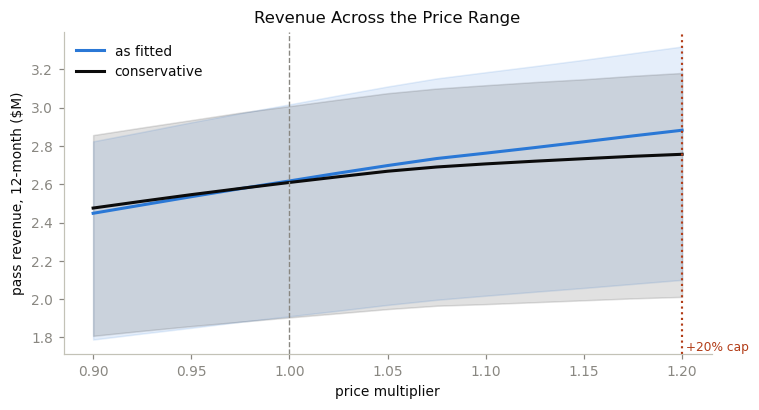

In [34]:
# Sweep Price Range
SWEEP_ITER = 400
CRN_SEED = 4242          # shared across every price and both cases
rows = []
for m in GRID:
    for label, rs, ds in [('as fitted', 1.0, 1.0),
                          ('conservative', RESPONSE_RATIO, DEPTH_BIAS)]:
        # Common random numbers: same economy/share draw at every price
        r = simulate(m, n_iter=SWEEP_ITER, response_scale=rs, depth_scale=ds,
                     rng=np.random.default_rng(CRN_SEED))
        rows.append({
            'price_multiplier': m, 'case': label,
            'p5': np.percentile(r, 5), 'median': np.median(r),
            'p95': np.percentile(r, 95),
        })

sw = pd.DataFrame(rows)
fitted = sw[sw.case == 'as fitted'].set_index('price_multiplier')
cons = sw[sw.case == 'conservative'].set_index('price_multiplier')

for df in (fitted, cons):
    df['lift_vs_base'] = df['median'] - df.loc[1.0, 'median']

print('As fitted')
display(fitted[['p5', 'median', 'p95', 'lift_vs_base']].round(0).astype(int).rename_axis(None))
print('Conservative')
display(cons[['p5', 'median', 'p95', 'lift_vs_base']].round(0).astype(int).rename_axis(None))

fig, ax = plt.subplots(figsize=(7, 3.8))
for df, lbl, col in [(fitted, 'as fitted', ACCENT), (cons, 'conservative', INK)]:
    ax.plot(df.index, df['median'] / 1e6, color=col, linewidth=2, label=lbl)
    ax.fill_between(df.index, df['p5'] / 1e6, df['p95'] / 1e6, color=col, alpha=0.12)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color='#b23c17', linestyle=':', linewidth=1.4)
ax.text(1.20, ax.get_ylim()[0], ' +20% cap', fontsize=8, color='#b23c17', va='bottom')
ax.set_xlabel('price multiplier')
ax.set_ylabel('pass revenue, 12-month ($M)')
ax.set_title('Revenue Across the Price Range')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 4 · Macroeconomic Scenarios

**Purpose:** Tests whether the recommendation holds if the economy turns, since the base case only averages over economic paths.

**Design Notes:**

1. Three scenarios run explicitly: contraction, base, expansion
2. The separation matters for the decision, not just the chart
  - A shortfall from a contracting market is a forecasting miss; a shortfall from customers rejecting the price is a pricing mistake
  - Only the second is reversible by changing the price back, and only the second is anyone's fault

**Observations:**

1. Median pass revenue at x1.20 rises in every scenario: $2.36M (contraction), $2.76M (base), $3.03M (expansion)
2. Gain from +20% ranges $0.13M-$0.16M across the three economies
3. The gain holds regardless of the macro forecast: the pricing decision doesn't hinge on which economy materializes


Median pass revenue, 12-month ($M)


,1.0,1.1,1.2
contraction,2.23,2.32,2.36
base,2.61,2.71,2.76
expansion,2.87,2.98,3.03


Gain from +20% within each economy ($M)


,gain
contraction,0.13
base,0.15
expansion,0.16


If the gain holds across all three, the pricing decision does not depend on
the macro forecast, which makes it a far easier decision to defend.


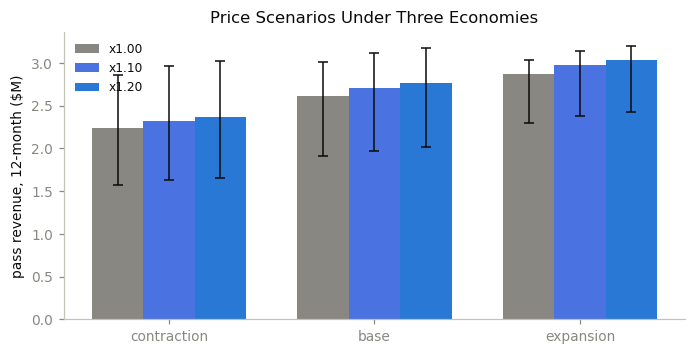

In [35]:
# Test Macro Scenarios
SCEN = {'contraction': -0.45, 'base': 0.0, 'expansion': +0.45}
KEY = [1.0, 1.10, 1.20]

rows = []
for name, shift in SCEN.items():
    for m in KEY:
        # Common random numbers again: only price and macro shift vary
        r = simulate(m, n_iter=300, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                     macro_shift=shift, rng=np.random.default_rng(CRN_SEED))
        rows.append({'scenario': name, 'price': m,
                     'p5': np.percentile(r, 5), 'median': np.median(r),
                     'p95': np.percentile(r, 95)})

sc = pd.DataFrame(rows)
piv = sc.pivot(index='scenario', columns='price', values='median').reindex(SCEN.keys())
print('Median pass revenue, 12-month ($M)')
display((piv / 1e6).round(2).rename_axis(None).rename_axis(None, axis=1))

print('Gain from +20% within each economy ($M)')
display(((piv[1.20] - piv[1.0]) / 1e6).round(2).to_frame('gain').rename_axis(None))
print('If the gain holds across all three, the pricing decision does not depend on')
print('the macro forecast, which makes it a far easier decision to defend.')

fig, ax = plt.subplots(figsize=(6.4, 3.3))
w = 0.25
for i, m in enumerate(KEY):
    s = sc[sc.price == m]
    x = np.arange(len(SCEN)) + (i - 1) * w
    ax.bar(x, s['median'].to_numpy() / 1e6, width=w,
           color=[MUTED, '#4a72e0', ACCENT][i], label=f'x{m:.2f}')
    ax.errorbar(x, s['median'].to_numpy() / 1e6,
                yerr=[(s['median'] - s['p5']).to_numpy() / 1e6,
                      (s['p95'] - s['median']).to_numpy() / 1e6],
                fmt='none', ecolor=INK, elinewidth=1, capsize=3)
ax.set_xticks(np.arange(len(SCEN)))
ax.set_xticklabels(list(SCEN.keys()))
ax.set_ylabel('pass revenue, 12-month ($M)')
ax.set_title('Price Scenarios Under Three Economies')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

---
## 5 · The Recommendation, and Its Honest Caveat

**Purpose:** States the recommendation and its caveat plainly.

**Design Notes:**

1. Read off the conservative case, since both §3/§6.2 biases point the same way, toward overstating safety

**Observations:**

1. Revenue-maximising price: x1.20; median 12-month gain $146,996 (conservative) vs. $264,760 (as fitted)
2. 5th-percentile outcome vs. no change: -$597,347, driven entirely by macro/demand uncertainty, not by any modelled downside
3. Probability the increase leaves the business worse off: 0.0%, since nothing in this analysis models a cost to raising price; the risk that remains is how large the gain turns out to be, not whether there is one
4. The optimum sits at the +20% ceiling, not inside the range: the cap chose this price, not the model

In [36]:
# Build Recommendation
best = cons['median'].idxmax()
lift = cons.loc[best, 'median'] - cons.loc[1.0, 'median']
lift_fit = fitted.loc[best, 'median'] - fitted.loc[1.0, 'median']
downside = cons.loc[best, 'p5'] - cons.loc[1.0, 'median']

display(pd.DataFrame({'value': [
    f'x{best:.3f}', f'${lift:,.0f}', f'${lift_fit:,.0f}', f'${downside:,.0f}',
]}, index=['revenue-maximising price', 'median 12-month gain (conservative)',
           'median 12-month gain (as fitted)', '5th-percentile outcome vs. no change']))

prob_worse = None
r_best = simulate(best, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
r_base = simulate(1.0, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
prob_worse = float((r_best < r_base).mean())
print(f'Probability the increase leaves us worse off: {prob_worse:.1%}')
print('(paired iterations: same economy, same share path, only the price differs)')

if best < GRID[-1] - 1e-9:
    print('\n' + '=' * 68)
    print(f'The optimum is INTERIOR at x{best:.3f}: revenue turns over before the')
    print('cap. This is a real optimum the model found rather than a constraint it')
    print('hit. The cap is not what limits the recommendation.')
    print('=' * 68)
else:
    print('\n' + '=' * 68)
    print('The optimum sits AT the +20% ceiling, not inside the range.')
    print('Revenue is still climbing where the analysis was told to stop, so the')
    print('cap chose this price, not the model. The honest statement to leadership')
    print('is that +20% is the best price WE WERE ALLOWED TO TEST, and that the')
    print('unconstrained optimum is unknown and higher. Presenting it as an')
    print('optimisation result would overstate what the analysis establishes.')
    print('=' * 68)

if prob_worse > 0.35:
    print(f'\nNOTE: at {prob_worse:.0%}, this is close to a coin flip. The median gain is')
    print('real but thin against the spread. Present it as a bet with a known')
    print('downside, not as a forecast.')

,value
revenue-maximising price,x1.200
median 12-month gain (conservative),"$146,996"
median 12-month gain (as fitted),"$264,760"
5th-percentile outcome vs. no change,"$-597,347"


Probability the increase leaves us worse off: 0.0%
(paired iterations: same economy, same share path, only the price differs)

The optimum sits AT the +20% ceiling, not inside the range.
Revenue is still climbing where the analysis was told to stop, so the
cap chose this price, not the model. The honest statement to leadership
is that +20% is the best price WE WERE ALLOWED TO TEST, and that the
unconstrained optimum is unknown and higher. Presenting it as an
optimisation result would overstate what the analysis establishes.


---
## 6 · Export for Power BI

**Purpose:** Writes the price sweep, macro scenarios, and assumptions that notebook 04 loads and the Power BI model displays.

**Design Notes:**

1. Assumptions travel with the export (illustrative figures alongside measured biases), so nothing is buried in a constant

**Observations:**

1. Three tables written: simulation price sweep, simulation scenarios, simulation assumptions


In [37]:
# Export results
sim_out = sw.copy()
sim_out['price_change_pct'] = (sim_out['price_multiplier'] - 1) * 100

scen_out = sc.copy()
scen_out['price_change_pct'] = (scen_out['price'] - 1) * 100

assump = pd.DataFrame({
    'assumption': ['response scale (conservative)', 'depth bias (conservative)',
                   'iterations per price', 'probability increase is worse'],
    'value': [RESPONSE_RATIO, DEPTH_BIAS, SWEEP_ITER, prob_worse],
    'note': ['measured, notebook 01 §6.2', 'measured, notebook 02 §5',
             '', 'paired iterations'],
})
display(assump.set_index('assumption').rename_axis(None))

display(save_tables({
    'simulation_price_sweep': sim_out,
    'simulation_scenarios': scen_out,
    'simulation_assumptions': assump,
}))

,value,note
response scale (conservative),1.485714,"measured, notebook 01 §6.2"
depth bias (conservative),1.055014,"measured, notebook 02 §5"
iterations per price,400.000000,
probability increase is worse,0.000000,paired iterations


,rows
simulation_price_sweep.parquet,26
simulation_scenarios.parquet,9
simulation_assumptions.parquet,4


---
## What this notebook establishes

| Result | Where | Why it matters |
|---|---|---|
| Correlated draws widen the distribution materially | §2.1 | Independent draws would report false precision |
| Two measured biases bracketed, not assumed away | §3 | The recommendation is read off the conservative case |
| The gain holds across economies | §4 | The decision does not hinge on a macro forecast |
| The cap binds | §5 | +20% is a constraint, not an optimum, and must be said that way |

### The one line to carry into the room

Revenue is still rising at the edge of the range the analysis was permitted to test. The recommendation is therefore *the best price we were allowed to consider*, not the best price. Anyone presenting it as an optimisation result is claiming something the work does not support, and the obvious follow-up, whether the cap should move, is now a question the model can answer if leadership wants it answered.

### Next

04_segmentation.ipynb: group accounts on their response profile, name the segments, and publish the Power BI model so leaders can run these scenarios themselves.

---


# 04 · Segmentation, Profiling and Handoff

**Purpose:** Answers who bears the impact of a price change, grouping accounts by their modelled response and publishing the result so the business can use it without another analysis.

**Context, for anyone starting here.** This case study evaluates a proposed international roaming price increase across the ~50,000-account synthetic book built in the data notebook. Notebook 03 puts a distribution on what that increase is worth over 12 months; this notebook asks who actually bears it.

**Design Notes:**

1. Segment on response, not on customers
  - Clustering on characteristics first produces groups that are easy to describe and analytically useless, since the thing being decided is price and the grouping was never about price
  - Accounts are grouped on their modelled response to a price change instead; characteristics are read back afterward to describe what each group turned out to be: profiling explains a segment, it doesn't create one
2. Group on the shape of the response, not its size
  - Two accounts can lose the same revenue by very different routes: one abandons the pass entirely, the other keeps it and quietly halves its days
  - Identical expected revenue, completely different interventions: one needs a retention offer, the other needs a cheaper short-duration option
  - A single sensitivity score collapses that distinction; the full probability vector preserves it

**Three deliverables**

| Section | Output |
|---|---|
| §2-4 | Segments, named and profiled |
| §5 | Where the revenue at stake actually sits, by segment |
| §6 | A star schema for Power BI so leaders run their own scenarios |


In [38]:
# Load inputs
trips = load_trips(with_macro=False)
accounts = load('accounts')
scored = load('scored_trips')
resp = load('account_price_response')
rev_tbl = load('revenue_by_state')
sim_sweep = load('simulation_price_sweep')
ground_truth = load('ground_truth')           # s3.1 validation only

print(f'{len(resp):,} accounts with a modelled price response')

29,406 accounts with a modelled price response


---
## 1 · The Clustering Input

**Purpose:** Builds six model-derived features per account for clustering, so segments describe response, not raw behavior.

**Design Notes:**

1. Six features, all derived from the model rather than raw behaviour

| Feature | What it captures |
|---|---|
| p_no_purchase at standard price | baseline walk-away risk |
| response_span | how far that risk moves across the range |
| p_reduces at +20% | tendency to trim rather than quit |
| p_increases at -10% | responsiveness to a discount |
| reduce_vs_quit | the shape: which route the loss takes |
| log(revenue) | value at stake, so segments are decision-relevant |

2. reduce_vs_quit is the feature doing the real work
  - Blends the account's current trim tendency (p_reduces at standard price) with its future walk-away risk at the top of the tested range (p_np at +20%)
  - High score: reduces often, rarely quits; low score: no-purchase risk dominates
  - Without it, an account that abandons the pass and one that halves its days land in the same cluster whenever their expected loss matches, and the segmentation stops being actionable
3. Revenue is included deliberately
  - A segment that behaves distinctively but carries no revenue is a curiosity; one that carries a quarter of the book is a decision
4. Feature correlations above 0.95 are treated as redundant
  - The strongest pairs are reduce_vs_quit/p_reduces (0.70), reduce_vs_quit/response_span (-0.65), and baseline_risk/response_span (0.65). All are moderate but acceptable, since reduce_vs_quit is deliberately doing shape work the others can't

**Observations:**

1. No redundant pairs above the 0.95 threshold
2. Highest correlations are reduce_vs_quit/p_reduces (0.70), reduce_vs_quit/response_span (-0.65), and baseline_risk/response_span (0.65), all accepted per the Design Notes above


In [39]:
# Build Clustering Features
sc = scored.merge(trips[['trip_id', 'pass_revenue']], on='trip_id', how='left')
acct_state = sc.groupby('account_id').agg(
    trips=('trip_id', 'size'),
    revenue=('pass_revenue', 'sum'),
    p_reduces=('p_reduces', 'mean'),
    p_increases=('p_increases', 'mean'),
).reset_index()

seg = resp.merge(acct_state, on='account_id', how='inner')
seg['baseline_risk'] = seg['p_np_1.00']
seg['response_span'] = seg['p_np_1.20'] - seg['p_np_0.90']
# Blends current trim tendency with future walk-away risk (see Design Notes)
seg['reduce_vs_quit'] = seg['p_reduces'] / (seg['p_reduces'] + seg['p_np_1.20'] + 1e-9)
seg['log_revenue'] = np.log1p(seg['revenue'])

FEATS = ['baseline_risk', 'response_span', 'p_reduces', 'p_increases',
         'reduce_vs_quit', 'log_revenue']
seg = seg.dropna(subset=FEATS)
display(seg[FEATS].describe().round(4))

corr = seg[FEATS].corr()
print('Feature correlations (moderate pairs near 0.65-0.70 are acceptable; see Design Notes)')
display(corr.round(2))
high = [(a, b, round(corr.loc[a, b], 3)) for i, a in enumerate(FEATS)
        for b in FEATS[i + 1:] if abs(corr.loc[a, b]) > 0.95]
print(f"Redundant pairs: {high if high else 'none'}")

,baseline_risk,response_span,p_reduces,p_increases,reduce_vs_quit,log_revenue
count,29406.0000,29406.0000,29406.0000,29406.0000,29406.0000,29406.0000
mean,0.1036,0.0357,0.1118,0.0637,0.4666,4.5717
std,0.0257,0.0266,0.0428,0.0097,0.1055,1.4235
min,0.0379,-0.0469,0.0000,0.0000,0.0000,0.0000
25%,0.0780,0.0207,0.0846,0.0613,0.3931,4.0604
50%,0.1030,0.0351,0.1049,0.0645,0.4576,4.7958
75%,0.1212,0.0453,0.1307,0.0683,0.5334,5.4424
max,0.5004,0.4232,0.6070,0.1056,0.9369,8.6953


Feature correlations (moderate pairs near 0.65-0.70 are acceptable; see Design Notes)


,baseline_risk,response_span,p_reduces,p_increases,reduce_vs_quit,log_revenue
baseline_risk,1.00,0.65,0.04,-0.21,-0.57,-0.18
response_span,0.65,1.00,-0.19,-0.14,-0.65,-0.05
p_reduces,0.04,-0.19,1.00,-0.31,0.70,-0.15
p_increases,-0.21,-0.14,-0.31,1.00,-0.07,0.04
reduce_vs_quit,-0.57,-0.65,0.70,-0.07,1.00,0.02
log_revenue,-0.18,-0.05,-0.15,0.04,0.02,1.00


Redundant pairs: none


---
## 2 · How Many Segments?

**Purpose:** Chooses the number of segments, weighing statistical separation against operational practicality.

**Design Notes:**

1. Statistical: silhouette score, measuring whether the clusters are actually separated
2. Practical: whether the business can act on the result
  - Nine segments needing their own price aren't a pricing strategy, they're a spreadsheet nobody will maintain
  - Four or five is the range where distinct treatment stays realistic
3. If the two disagree, the practical criterion wins: an unimplementable segmentation delivers nothing regardless of its silhouette

**Observations:**

1. Silhouette peaks at a higher k (k=6) than chosen; k=5 is picked instead for operational actionability
2. Smallest segment stays well above a trivial share at k=5, confirming five is a workable split


,inertia,silhouette,smallest segment
2,134467.6844,0.2660,0.4201
3,115409.0852,0.2606,0.1266
4,102073.5650,0.2832,0.0642
5,89043.7145,0.2999,0.0257
6,77831.4134,0.3114,0.0203
7,69915.6985,0.2842,0.0196
8,63125.2571,0.2499,0.0045


Silhouette argmax at k=6 (0.311); chosen k=5 (0.300)
Enough separation to distinguish the response shapes, few enough that each
segment can carry a distinct pricing treatment someone will actually run.


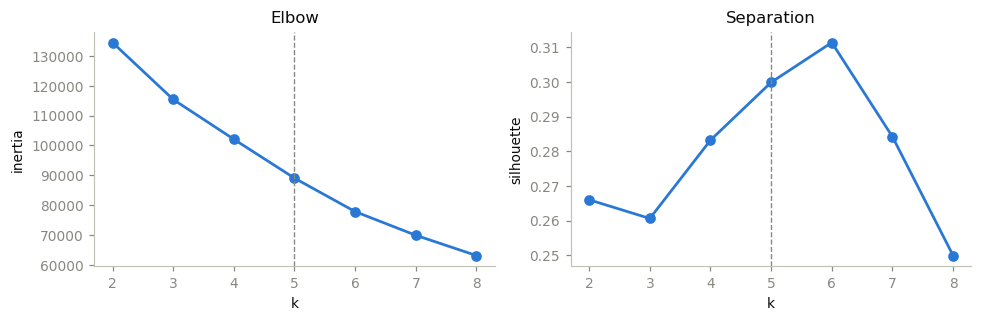

In [40]:
# Choose Segment Count
Z = StandardScaler().fit_transform(seg[FEATS])
sample = np.random.default_rng(0).choice(len(Z), size=min(8000, len(Z)), replace=False)

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    sizes = pd.Series(km.labels_).value_counts(normalize=True)
    rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(Z[sample], km.labels_[sample]),
        'smallest segment': sizes.min(),
    })
k_tbl = pd.DataFrame(rows).set_index('k').round(4)
display(k_tbl.rename_axis(None))

K = 5
best_k = int(k_tbl['silhouette'].idxmax())
print(f"Silhouette argmax at k={best_k} ({k_tbl.loc[best_k, 'silhouette']:.3f}); "
      f"chosen k={K} ({k_tbl.loc[K, 'silhouette']:.3f})")
print('Enough separation to distinguish the response shapes, few enough that each')
print('segment can carry a distinct pricing treatment someone will actually run.')

km = KMeans(n_clusters=K, n_init=20, random_state=0).fit(Z)
seg['cluster'] = km.labels_

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(k_tbl.index, k_tbl['inertia'], marker='o', color=ACCENT, linewidth=1.8)
axes[0].axvline(K, color=MUTED, linestyle='--', linewidth=0.9)
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].set_title('Elbow')
axes[1].plot(k_tbl.index, k_tbl['silhouette'], marker='o', color=ACCENT, linewidth=1.8)
axes[1].axvline(K, color=MUTED, linestyle='--', linewidth=0.9)
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette')
axes[1].set_title('Separation')
plt.tight_layout()
plt.show()

---
## 3 · Profiling: What Did the Clusters Turn Out to Be?

**Purpose:** Reads the clusters' characteristics back, turning an anonymous cluster number into a group a product owner recognizes.

**Design Notes:**

1. The clusters exist in response space and have no names: profiling explains what they turned out to be
2. Every column here is descriptive; none of it went into the clustering
3. Segments named from rank thresholds on span/shape/value, not by hand
  - Dormant: revenue share below 0.5% (travels but never buys)
  - Anchor: low span, high value; Steady: low span; Trimmers: high span + high shape; Flight risk: high span; else Swing
  - Duplicate names split by a value qualifier (higher/mid/lower value)

**Observations:**

1. 1,479 accounts (5.0%) set aside as dormant, carrying 0.02% of revenue: travel but never buy, a conversion question rather than a pricing one
2. Five segments named: Flight risk (2.6% of accounts, 2.4% of revenue, highest walk-away sensitivity), Swing higher value (32.2% of accounts, 44.3% of revenue, 87% business), Steady (9.5% of accounts, barely moves), Dormant (5.0%, excluded from pricing), Swing mid value (50.6% of accounts, half of revenue)
3. Business share ranges from 2% (Swing mid value) to 87% (Swing higher value) across segments: a real behavioral split, not noise


In [41]:
# Profile Segments
prof = seg.merge(accounts[['account_id', 'is_business', 'lines_on_account',
                          'tenure_months', 'plan_tier']], on='account_id', how='left')
trip_ch = trips.groupby('account_id').agg(
    avg_days=('days_traveled', 'mean'),
    avg_party=('lines_traveling', 'mean'),
    top_region=('region', lambda s: s.mode().iat[0] if len(s) else 'n/a'),
    avg_ease=('substitute_ease', 'mean'),
).reset_index()
prof = prof.merge(trip_ch, on='account_id', how='left')

summary = prof.groupby('cluster').agg(
    accounts=('account_id', 'size'),
    revenue=('revenue', 'sum'),
    rev_per_acct=('revenue', 'mean'),
    trips_per_acct=('trips', 'mean'),
    business=('is_business', 'mean'),
    avg_days=('avg_days', 'mean'),
    avg_party=('avg_party', 'mean'),
    tenure=('tenure_months', 'mean'),
    ease=('avg_ease', 'mean'),
    baseline_risk=('baseline_risk', 'mean'),
    response_span=('response_span', 'mean'),
    reduce_vs_quit=('reduce_vs_quit', 'mean'),
)
summary['rev_share'] = summary['revenue'] / summary['revenue'].sum()
summary['acct_share'] = summary['accounts'] / summary['accounts'].sum()

print('Segment profiles: response features first, characteristics after')
display(summary[['accounts', 'acct_share', 'rev_share', 'rev_per_acct',
                 'baseline_risk', 'response_span', 'reduce_vs_quit']].round(4).rename_axis(None))
display(summary[['business', 'trips_per_acct', 'avg_days', 'avg_party',
                 'tenure', 'ease']].round(2).rename_axis(None))

print('Dominant destination by segment')
display(prof.groupby('cluster')['top_region']
        .agg(lambda s: s.value_counts(normalize=True).round(2).head(2).to_dict())
        .to_frame('top regions').rename_axis(None))

Segment profiles: response features first, characteristics after


,accounts,acct_share,rev_share,rev_per_acct,baseline_risk,response_span,reduce_vs_quit
0,756,0.0257,0.0237,168.8869,0.1349,0.0949,0.3950
1,9480,0.3224,0.4432,252.0401,0.0771,0.0194,0.5283
2,2799,0.0952,0.0334,64.3346,0.0976,0.0177,0.6428
3,1479,0.0503,0.0002,0.7076,0.1205,0.0461,0.4179
4,14892,0.5064,0.4996,180.8714,0.1182,0.0455,0.4026


,business,trips_per_acct,avg_days,avg_party,tenure,ease
0,0.03,1.71,9.23,1.73,76.67,0.76
1,0.87,5.62,4.59,1.31,73.98,0.62
2,0.36,1.75,3.65,1.33,72.49,0.64
3,0.07,1.06,7.02,1.52,71.18,0.68
4,0.02,2.25,7.49,1.58,72.40,0.64


Dominant destination by segment


,top regions
0,"{'europe': 0.61, 'asia': 0.19}"
1,"{'europe': 0.31, 'caribbean': 0.23}"
2,"{'asia': 0.25, 'europe': 0.24}"
3,"{'europe': 0.39, 'asia': 0.18}"
4,"{'europe': 0.3, 'asia': 0.21}"


In [42]:
# Name Segments
sp = summary.copy()
sp['rank_span'] = sp['response_span'].rank(pct=True)
sp['rank_shape'] = sp['reduce_vs_quit'].rank(pct=True)
sp['rank_value'] = sp['rev_per_acct'].rank(pct=True)


# Dormant threshold: travelled but never bought (see Design Notes)
DORMANT_REV_SHARE = 0.005
sp['dormant'] = summary['rev_share'] < DORMANT_REV_SHARE


def name_segment(r):
    # Rank thresholds chosen for a small, recognisable label set at K=5 (see §3)
    if r['dormant']:
        return 'Dormant: travels, does not buy'
    if r['rank_span'] <= 0.3 and r['rank_value'] >= 0.6:
        return 'Anchor: high value, low sensitivity'
    if r['rank_span'] <= 0.35:
        return 'Steady: barely notices the price'
    if r['rank_span'] >= 0.7 and r['rank_shape'] >= 0.6:
        return 'Trimmers: stay but buy less'
    if r['rank_span'] >= 0.7:
        return 'Flight risk: walks away'
    return 'Swing: moves at the margin'


summary['segment'] = sp.apply(name_segment, axis=1)
summary['is_dormant'] = sp['dormant']

# Duplicate names get a value qualifier (see Design Notes)
for nm, grp in list(summary.groupby('segment')):
    if len(grp) == 1:
        continue
    ranked = grp['rev_per_acct'].rank(ascending=False)
    qual = {1: 'higher value', 2: 'mid value', 3: 'lower value'}
    for i in grp.index:
        head, _, tail = nm.partition(': ')
        summary.loc[i, 'segment'] = f"{head} ({qual.get(int(ranked[i]), 'other')}): {tail}"

NAMES = summary['segment'].to_dict()
prof['segment'] = prof['cluster'].map(NAMES)
seg['segment'] = seg['cluster'].map(NAMES)

n_dorm = int(summary['is_dormant'].sum())
if n_dorm:
    d = summary[summary['is_dormant']]
    print(f"Set aside as dormant: {int(d['accounts'].sum()):,} accounts "
          f"({d['acct_share'].sum():.1%}) carrying {d['rev_share'].sum():.2%} of revenue.")
    print('They travel but never buy the pass, so no price answers them. They are a')
    print('conversion question, not a pricing one, and are excluded from §4-§5.\n')

print('Segments')
display(summary.set_index('segment')[[
    'accounts', 'acct_share', 'rev_share', 'rev_per_acct',
    'baseline_risk', 'response_span', 'business', 'trips_per_acct',
]].round(3).rename_axis(None))

Set aside as dormant: 1,479 accounts (5.0%) carrying 0.02% of revenue.
They travel but never buy the pass, so no price answers them. They are a
conversion question, not a pricing one, and are excluded from §4-§5.

Segments


,accounts,acct_share,rev_share,rev_per_acct,baseline_risk,response_span,business,trips_per_acct
Flight risk: walks away,756,0.026,0.024,168.887,0.135,0.095,0.026,1.713
Swing (higher value): moves at the margin,9480,0.322,0.443,252.040,0.077,0.019,0.868,5.618
Steady: barely notices the price,2799,0.095,0.033,64.335,0.098,0.018,0.357,1.745
"Dormant: travels, does not buy",1479,0.050,0.000,0.708,0.121,0.046,0.067,1.065
Swing (mid value): moves at the margin,14892,0.506,0.500,180.871,0.118,0.045,0.019,2.254


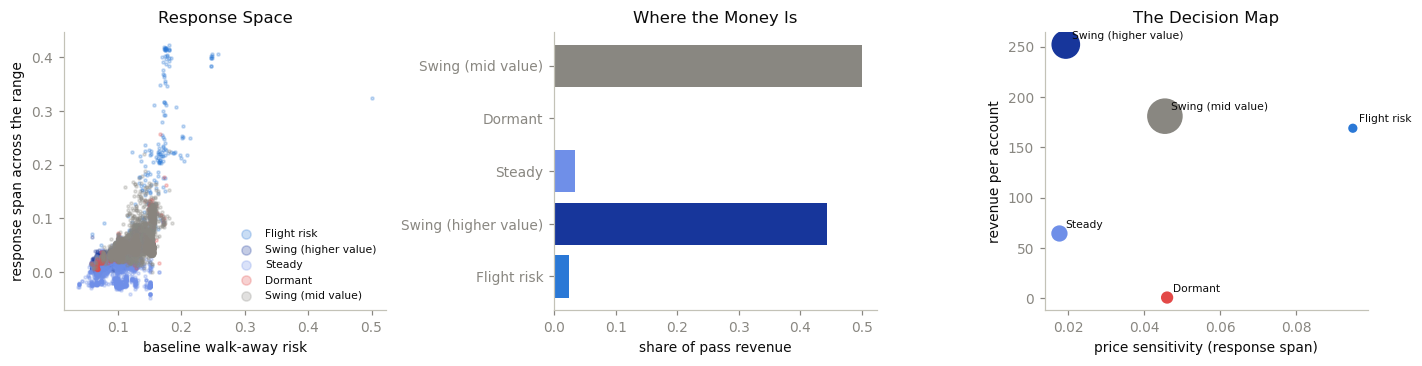

The third panel is the one to put in front of leadership: upper-left is
where a price increase earns most and risks least.


In [43]:
# Plot: Segment Profiles
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for i, c in enumerate(summary.index):
    m = seg['cluster'] == c
    axes[0].scatter(seg.loc[m, 'baseline_risk'], seg.loc[m, 'response_span'],
                    s=4, alpha=0.25, color=PALETTE[i % len(PALETTE)],
                    label=summary.loc[c, 'segment'].split(': ')[0])
axes[0].set_xlabel('baseline walk-away risk')
axes[0].set_ylabel('response span across the range')
axes[0].set_title('Response Space')
axes[0].legend(frameon=False, fontsize=7, markerscale=3)

axes[1].barh(summary['segment'].str.split(': ').str[0], summary['rev_share'],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
axes[1].set_xlabel('share of pass revenue')
axes[1].set_title('Where the Money Is')

axes[2].scatter(summary['response_span'], summary['rev_per_acct'],
                s=summary['accounts'] / 30,
                color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
for c in summary.index:
    axes[2].annotate(summary.loc[c, 'segment'].split(': ')[0],
                     (summary.loc[c, 'response_span'], summary.loc[c, 'rev_per_acct']),
                     fontsize=7, xytext=(4, 4), textcoords='offset points')
axes[2].set_xlabel('price sensitivity (response span)')
axes[2].set_ylabel('revenue per account')
axes[2].set_title('The Decision Map')
plt.tight_layout()
plt.show()

print('The third panel is the one to put in front of leadership: upper-left is')
print('where a price increase earns most and risks least.')

### 3.1 Are the Segments Real?

**Purpose:** Checks that the clusters reflect real structure, not an artifact of the algorithm.

**Design Notes:**

1. Stability: refit on random halves of the data
  - If accounts land together consistently, the structure is in the data; if assignments shuffle, it's in the algorithm
2. Recovery: because the data is synthetic, true sensitivity is known
  - Segments that separate on true sensitivity are finding the real mechanism, not a projection artefact: the check production data can never provide

**Observations:**

1. Split-half agreement: 97.6% (mean of 5 splits), well above the ~80% bar for structure being in the data
2. True sensitivity spans 0.809 across segments, confirming a wide, real spread
3. Rank correlation between true sensitivity and modelled span: -0.50 (negative is correct: more negative true sensitivity means a wider modelled span)


In [44]:
# Validate Segment Stability
rng = np.random.default_rng(5)


# Nearest centroid by hand: .predict() breaks on some older OpenBLAS builds
def assign(centers):
    d = ((Z[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return d.argmin(axis=1)


agree = []
for _ in range(5):
    half = rng.random(len(Z)) < 0.5
    a = KMeans(n_clusters=K, n_init=10, random_state=1).fit(Z[half])
    b = KMeans(n_clusters=K, n_init=10, random_state=2).fit(Z[~half])

    la = assign(a.cluster_centers_)
    lb = assign(b.cluster_centers_)
    ct = pd.crosstab(la, lb)
    agree.append(ct.max(axis=1).sum() / ct.values.sum())
print(f'Split-half agreement: {np.mean(agree):.1%} (mean of 5 splits)')
print('Above ~80% means the structure is in the data, not the algorithm.')

gt = prof.merge(ground_truth[['account_id', 'price_sensitivity', 'sensitivity_decile']],
                on='account_id', how='inner')
recov = gt.groupby('segment').agg(
    accounts=('account_id', 'size'),
    true_sensitivity=('price_sensitivity', 'mean'),
    modelled_span=('response_span', 'mean'),
).round(4).sort_values('true_sensitivity')
print('True sensitivity by segment (less negative = less sensitive)')
display(recov.rename_axis(None))

spread = recov['true_sensitivity'].max() - recov['true_sensitivity'].min()
print(f'Spread in true sensitivity across segments: {spread:.3f}')
print('A wide spread means the segments capture the real mechanism. Near zero')
print('would mean they separate on something else entirely.')

check = recov['true_sensitivity'].corr(recov['modelled_span'], method='spearman')
print(f'Rank correlation, true sensitivity vs modelled span: {check:+.2f}')
print('(negative is correct: more negative true sensitivity = wider modelled span)')

Split-half agreement: 97.6% (mean of 5 splits)
Above ~80% means the structure is in the data, not the algorithm.
True sensitivity by segment (less negative = less sensitive)


,accounts,true_sensitivity,modelled_span
Swing (mid value): moves at the margin,14892,-1.4450,0.0455
"Dormant: travels, does not buy",1479,-1.4389,0.0461
Flight risk: walks away,756,-1.3984,0.0949
Steady: barely notices the price,2799,-1.1534,0.0177
Swing (higher value): moves at the margin,9480,-0.6359,0.0194


Spread in true sensitivity across segments: 0.809
A wide spread means the segments capture the real mechanism. Near zero
would mean they separate on something else entirely.
Rank correlation, true sensitivity vs modelled span: -0.50
(negative is correct: more negative true sensitivity = wider modelled span)


---
## 4 · What Price Does Each Segment Want?

**Purpose:** Builds a segment-level revenue curve, since a single company-wide price is chosen for a population that doesn't exist.

**Design Notes:**

1. Rebuilt per segment from the state probabilities and revenue table, using the same arithmetic as notebook 03, restricted to each group's trips
2. Matches notebook 03 exactly on horizon (last 12 months) and case (conservative), so the two notebooks can't recommend different prices on a technicality

**Observations:**

1. Horizon: last 12 months, 52,500 trips, matches notebook 03
2. Cross-check against notebook 03's conservative case: consistent, same decision (x1.20), same order of magnitude gain
3. Optimum sits at the cap for three of the four priced segments; Steady, the least price-sensitive, peaks near x1.05 with a comparatively small gain

horizon: last 12 months, 52,500 trips: same as notebook 03
case: conservative, response x1.49, depth x1.06

Revenue vs no change, by segment


,"Dormant: travels, does not buy",Flight risk: walks away,Steady: barely notices the price,Swing (higher value): moves at the margin,Swing (mid value): moves at the margin
0.9,-0.0448,-0.0421,-0.0467,-0.0567,-0.0464
1.0,0.0000,0.0000,0.0000,0.0000,0.0000
1.1,0.0328,0.0262,0.0025,0.0446,0.0341
1.2,0.0470,0.0356,0.0052,0.0698,0.0512


Cross-check against notebook 03, conservative case
  best price    04 x1.200    03 x1.200
  gain at best  04 $170,719    03 $146,996
  Consistent: same decision, same arithmetic.

Optimal price by segment


,best price,gain at best,gain at +20%,revenue share
Flight risk: walks away,1.20,2481.7077,2481.7077,0.0237
Steady: barely notices the price,1.05,1992.8809,505.0325,0.0334
Swing (higher value): moves at the margin,1.20,92140.1936,92140.1936,0.4432
Swing (mid value): moves at the margin,1.20,75592.3457,75592.3457,0.4996


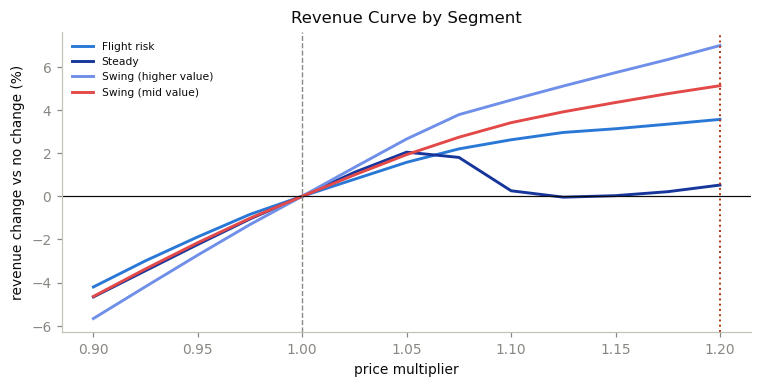

In [45]:
# Build segment revenue curves
sweep = load('price_sweep').set_index('price_multiplier')
GRID = np.round(np.sort(rev_tbl['price_multiplier'].unique()), 4)

trip_seg = trips[['trip_id', 'account_id']].merge(
    seg[['account_id', 'segment']], on='account_id', how='inner')
p_std = scored.set_index('trip_id')[[f'p_{c}' for c in CLASSES]]
rev_w = rev_tbl.pivot_table(index='trip_id', columns='price_multiplier',
                            values=[f'rev_{c}' for c in CLASSES])

# Match notebook 03's horizon and case exactly (see Design Notes)
asm0 = load('simulation_assumptions').set_index('assumption')['value']
RESPONSE_SCALE = float(asm0.get('response scale (conservative)', 1.0))
DEPTH_SCALE = float(asm0.get('depth bias (conservative)', 1.0))

FWD = trips[trips['month'] >= trips['month'].max() - 11]['trip_id'].to_numpy()
print(f'horizon: last 12 months, {len(FWD):,} trips: same as notebook 03')
print(f'case: conservative, response x{RESPONSE_SCALE:.2f}, depth x{DEPTH_SCALE:.2f}\n')

ids = trip_seg['trip_id'].to_numpy()
ids = ids[np.isin(ids, p_std.index) & np.isin(ids, rev_w.index) & np.isin(ids, FWD)]
trip_seg = trip_seg[trip_seg.trip_id.isin(ids)]
P0 = p_std.loc[ids].to_numpy()
I_RED, I_UNCH = CLASSES.index('reduces'), CLASSES.index('unchanged')

prob_by_price = {}
rows = []
for m in GRID:
    P = apply_price_shift(P0, price_shift_logodds(sweep, m), RESPONSE_SCALE)
    prob_by_price[float(m)] = P
    R = np.column_stack([rev_w[(f'rev_{c}', m)].loc[ids].to_numpy() for c in CLASSES]).copy()
    # Deepen reductions by the measured contamination bias, as notebook 03 does
    R[:, I_RED] = np.clip(R[:, I_UNCH] - DEPTH_SCALE * (R[:, I_UNCH] - R[:, I_RED]), 0, None)
    er = (P * R).sum(axis=1)
    rows.append(pd.DataFrame({'segment': trip_seg['segment'].to_numpy(),
                              'price_multiplier': m, 'revenue': er})
                .groupby(['segment', 'price_multiplier'])['revenue'].sum().reset_index())

seg_curve = pd.concat(rows, ignore_index=True)
piv = seg_curve.pivot(index='price_multiplier', columns='segment', values='revenue')
rel = (piv / piv.loc[1.0] - 1)

print('Revenue vs no change, by segment')
display(rel.iloc[::4].round(4).rename_axis(None).rename_axis(None, axis=1))

# Dormant accounts carry no revenue and can't respond to price; excluded from here on
piv = piv[[c for c in piv.columns if not c.startswith('Dormant')]]
rel = rel[piv.columns]

# Cross-check against notebook 03: a gap here would be a defect, not a modelling choice
try:
    s5 = sim_sweep[sim_sweep.case == 'conservative'].set_index('price_multiplier')
    b6, b5 = float(piv.sum(axis=1).idxmax()), float(s5['median'].idxmax())
    g6 = float(piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0])
    g5 = float(s5['median'].max() - s5['median'].loc[1.0])
    print('Cross-check against notebook 03, conservative case')
    print(f'  best price    04 x{b6:.3f}    03 x{b5:.3f}')
    print(f'  gain at best  04 ${g6:,.0f}    03 ${g5:,.0f}')
    if abs(g6 - g5) > 0.5 * max(abs(g5), 1.0):
        print('  WARNING: the two disagree by more than half. Check horizon and')
        print('  conservative scaling.')
    else:
        print('  Consistent: same decision, same arithmetic.')
except Exception as exc:
    print(f'cross-check unavailable: {exc}')
print()

best = pd.DataFrame({
    'best price': piv.idxmax(),
    'gain at best': (piv.max() - piv.loc[1.0]),
    'gain at +20%': (piv.loc[GRID[-1]] - piv.loc[1.0]),
    'revenue share': summary.set_index('segment')['rev_share'].reindex(piv.columns),
}).round(4)
print('Optimal price by segment')
display(best.rename_axis(None))

fig, ax = plt.subplots(figsize=(7, 3.6))
for i, s in enumerate(piv.columns):
    ax.plot(rel.index, rel[s] * 100, linewidth=1.9,
            color=PALETTE[i % len(PALETTE)], label=s.split(': ')[0])
ax.axhline(0, color=INK, linewidth=0.8)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color='#b23c17', linestyle=':', linewidth=1.3)
ax.set_xlabel('price multiplier')
ax.set_ylabel('revenue change vs no change (%)')
ax.set_title('Revenue Curve by Segment')
ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

---
## 5 · Uniform Against Selective

**Purpose:** Decides between one price for everyone and each segment's own optimum: the comparison that decides the recommendation.

**Design Notes:**

1. The gap is the value of having segmented at all
  - Small gap: a uniform increase is sufficient, a genuinely useful and cheaper finding
  - Large gap: segmentation has earned the operational complexity it costs (separate rate plans, billing, customer-facing explanation, a fairness question about charging different customers differently)

**Observations:**

1. Uniform, best single price: x1.20, gain $170,719
2. Selective, each segment's own best: $172,207
3. Value of segmenting: $1,488 (+0.9%), well under 5%, so a uniform increase captures nearly all the value
4. Retention priority ranks segments by value at stake × sensitivity, headed by Flight risk despite its small size


In [46]:
# Compare Uniform vs. Selective
uniform_best = piv.sum(axis=1).idxmax()
uniform_gain = piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0]
selective_gain = float(best['gain at best'].sum())
cap_gain = float(best['gain at +20%'].sum())

print(f'Uniform, best single price      x{uniform_best:.3f}   ${uniform_gain:,.0f}')
print(f'Uniform at the +20% cap         x{GRID[-1]:.3f}   ${cap_gain:,.0f}')
print(f"Selective, each segment's best             ${selective_gain:,.0f}")
print(f'\nValue of segmenting: ${selective_gain - uniform_gain:,.0f} '
      f'({(selective_gain / max(uniform_gain, 1e-9) - 1):+.1%})')

all_at_cap = bool((best['best price'] >= GRID[-1] - 1e-9).all())

if all_at_cap:
    print('\n' + '=' * 68)
    print("Every segment's optimum sits AT the +20% cap, so selective and uniform")
    print('pricing are identical BY CONSTRUCTION. This has not shown that')
    print('segmentation adds nothing: it has shown the cap binds everywhere,')
    print('which makes the question unanswerable inside the permitted range.')
    print('\nSegmentation still earns its place, for two other things: which')
    print('customers to fund retention against, and which segments would separate')
    print('first if the ceiling moved. Both are below.')
    print('=' * 68)
elif selective_gain - uniform_gain < 0.05 * max(uniform_gain, 1):
    print('\nThe gap is under 5%. A uniform increase captures nearly all of the value,')
    print("and the segmentation's job becomes identifying who to protect with")
    print('retention rather than who to charge differently. That is simpler to run')
    print('and easier to defend.')
else:
    print('\nSelective pricing earns materially more. Weigh it against the operational')
    print('cost: separate rate plans, billing changes, and a fairness question about')
    print('charging different customers differently for the same product.')

# Slope at the ceiling shows who still has room if the cap lifted
tail = piv.tail(3)
slope = ((tail.iloc[-1] - tail.iloc[0]) / tail.iloc[0]).sort_values(ascending=False)
print('Revenue slope over the last three price steps (headroom at the cap)')
display(slope.round(4).to_frame('slope').rename_axis(None))
print('Steeper = still climbing, so most to gain if the ceiling moved.')

# Who to protect: high value, high sensitivity
protect = summary[~summary['is_dormant']].assign(
    risk_value=summary.loc[~summary['is_dormant'], 'response_span']
    * summary.loc[~summary['is_dormant'], 'rev_per_acct']
).sort_values('risk_value', ascending=False)
print('Retention priority: value at stake x sensitivity')
display(protect[['segment', 'accounts', 'rev_per_acct', 'response_span', 'risk_value']]
        .round(3).set_index('segment').rename_axis(None))

Uniform, best single price      x1.200   $170,719
Uniform at the +20% cap         x1.200   $170,719
Selective, each segment's best             $172,207

Value of segmenting: $1,488 (+0.9%)

The gap is under 5%. A uniform increase captures nearly all of the value,
and the segmentation's job becomes identifying who to protect with
retention rather than who to charge differently. That is simpler to run
and easier to defend.
Revenue slope over the last three price steps (headroom at the cap)


,slope
Swing (higher value): moves at the margin,0.0119
Swing (mid value): moves at the margin,0.0075
Steady: barely notices the price,0.0049
Flight risk: walks away,0.0042


Steeper = still climbing, so most to gain if the ceiling moved.
Retention priority: value at stake x sensitivity


,accounts,rev_per_acct,response_span,risk_value
Flight risk: walks away,756,168.887,0.095,16.031
Swing (mid value): moves at the margin,14892,180.871,0.045,8.225
Swing (higher value): moves at the margin,9480,252.040,0.019,4.888
Steady: barely notices the price,2799,64.335,0.018,1.140


---
## 6 · Power BI Handoff

**Purpose:** Publishes a star schema, not a flat extract, so leaders can run their own scenarios in Power BI without writing DAX to work around a denormalised table.

**Portfolio note.** The engagement shipped this as a Power BI report. The public version of the same handoff is a standalone [interactive scenario page](https://paforsey.datafxlab.com/case-studies/international-roaming/scenario-analysis/scenario-analysis.html) built from these same tables.

**Design Notes:**

1. Three fact tables sharing two dimensions

```
              dim_segment ──┐
                            ├── fact_segment_revenue   (segment x price)
              dim_price ────┤── fact_scenario          (scenario x price)
                            └── fact_simulation        (price, p5/median/p95)
```

2. What a leader can do with it without asking for a new analysis
  - Move the price anywhere in the range and watch the revenue distribution move
  - Switch between expansion, base, and contraction
  - Filter to a segment to see who carries the upside and who carries the risk
  - Read the range rather than a point, with the downside visible next to the median
3. dim_assumption travels with the model on purpose: a scenario tool that hides what it assumes gets used long after its assumptions expire

**Observations:**

1. Seven tables written: three dimension/fact pairs plus the account-level segment assignment


In [47]:
# Export Power BI Tables
dim_segment = summary.reset_index()[['cluster', 'segment', 'accounts', 'acct_share',
                                     'rev_share', 'rev_per_acct', 'business',
                                     'trips_per_acct', 'avg_days', 'avg_party',
                                     'tenure', 'baseline_risk', 'response_span',
                                     'reduce_vs_quit']].copy()
dim_segment = dim_segment.rename(columns={'cluster': 'segment_id'})
dim_segment = dim_segment.merge(summary.reset_index()[['cluster', 'is_dormant']]
                                .rename(columns={'cluster': 'segment_id'}),
                                on='segment_id', how='left')
dim_segment['headline'] = dim_segment['segment'].str.split(': ').str[0]
dim_segment['description'] = dim_segment['segment'].str.split(': ').str[-1]

dim_price = pd.DataFrame({'price_multiplier': GRID})
dim_price['price_change_pct'] = ((dim_price['price_multiplier'] - 1) * 100).round(2)
dim_price['first_line_price'] = (10.0 * dim_price['price_multiplier']).round(2)
dim_price['addl_line_price'] = (5.0 * dim_price['price_multiplier']).round(2)
dim_price['within_cap'] = dim_price['price_multiplier'] <= 1.20

name_to_id = dict(zip(dim_segment['segment'], dim_segment['segment_id']))
fact_segment_revenue = seg_curve.copy()
fact_segment_revenue['segment_id'] = fact_segment_revenue['segment'].map(name_to_id)
fact_segment_revenue = fact_segment_revenue.merge(
    seg_curve[seg_curve.price_multiplier == 1.0][['segment', 'revenue']]
    .rename(columns={'revenue': 'revenue_at_base'}), on='segment', how='left')
fact_segment_revenue['revenue_vs_base'] = (fact_segment_revenue['revenue']
                                           - fact_segment_revenue['revenue_at_base'])

fact_simulation = sim_sweep.copy()
fact_scenario = load('simulation_scenarios')
dim_assumption = load('simulation_assumptions')

account_segment = seg[['account_id', 'cluster', 'segment', 'revenue',
                       'baseline_risk', 'response_span']].rename(
    columns={'cluster': 'segment_id'})

BI = DATA.parent / 'powerbi'
summary = save_tables({
    'dim_segment': dim_segment,
    'dim_price': dim_price,
    'dim_assumption': dim_assumption,
    'fact_segment_revenue': fact_segment_revenue,
    'fact_simulation': fact_simulation,
    'fact_scenario': fact_scenario,
    'account_segment': account_segment,
}, dest=BI, with_cols=True)

print(f'Written to {BI.resolve()}')
display(summary)
print('Relationships to set in Power BI:')
print('  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]')
print('  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]')
print('  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]')
print('  dim_segment[segment_id]      1 -> * account_segment[segment_id]')

Written to /Users/paforsey/Inbox/Projects/data-science-portfolio/case-studies/international-roaming/data/powerbi


,rows,cols
dim_segment.parquet,5,17
dim_price.parquet,13,5
dim_assumption.parquet,4,3
fact_segment_revenue.parquet,65,6
fact_simulation.parquet,26,6
fact_scenario.parquet,9,6
account_segment.parquet,29406,6


Relationships to set in Power BI:
  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]
  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]
  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]
  dim_segment[segment_id]      1 -> * account_segment[segment_id]


In [48]:
# Define Power BI Measures
measures = pd.DataFrame({
    'measure': [
        'Net Revenue', 'Revenue vs Base', 'Downside (p5)', 'Upside (p95)',
        'Risk Band', 'Accounts at Risk', 'Segment Revenue Share',
    ],
    'dax': [
        'SUM(fact_simulation[median])',
        'SUM(fact_simulation[median]) - CALCULATE(SUM(fact_simulation[median]), '
        'dim_price[price_multiplier] = 1)',
        'SUM(fact_simulation[p5])',
        'SUM(fact_simulation[p95])',
        'SUM(fact_simulation[p95]) - SUM(fact_simulation[p5])',
        'SUM(fact_simulation[accounts_lost])',
        'DIVIDE(SUM(fact_segment_revenue[revenue]), '
        'CALCULATE(SUM(fact_segment_revenue[revenue]), ALL(dim_segment)))',
    ],
    'note': [
        'always show with the band, never alone',
        'the number leadership asked for',
        'the number that should drive the decision',
        '', 'width of the band = how much is unknown',
        'relationship value, not pass revenue', '',
    ],
})
display(measures.set_index('measure').rename_axis(None))

path = BI / ('measures.csv')
measures.to_csv(path, index=False)
print(f'Written {path.name}')

,dax,note
Net Revenue,SUM(fact_simulation[median]),"always show with the band, never alone"
Revenue vs Base,SUM(fact_simulation[median]) - CALCULATE(SUM(f...,the number leadership asked for
Downside (p5),SUM(fact_simulation[p5]),the number that should drive the decision
Upside (p95),SUM(fact_simulation[p95]),
Risk Band,SUM(fact_simulation[p95]) - SUM(fact_simulatio...,width of the band = how much is unknown
Accounts at Risk,SUM(fact_simulation[accounts_lost]),"relationship value, not pass revenue"
Segment Revenue Share,"DIVIDE(SUM(fact_segment_revenue[revenue]), CAL...",


Written measures.csv


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Segments built on response, not characteristics | §1 | The grouping is about the decision being made |
| Shape separated from size | §1 | Abandonment and trimming get different treatments |
| k chosen on actionability, not only silhouette | §2 | A segmentation someone will actually run |
| Segments stable and recover true sensitivity | §3.1 | The structure is in the data, not the algorithm |
| Segment-level revenue curves | §4 | Where an increase earns and where it costs |
| Uniform vs selective quantified | §5 | The value of segmenting, against its operational cost |
| Star schema and measures published | §6 | Leaders run scenarios without a new analysis |

### The complete chain

| Notebook | Question it answers |
|---|---|
| data/00_generate_and_validate_data.ipynb | What would the data look like, and is it usable? |
| 01 | Which state does a trip land in, at any price? |
| 02 | How big is the move, given the state? |
| 03 | What does a year of this look like, and how wrong could it be? |
| 04 | Who does it happen to, and what should we do about it? |

### Two things to say plainly when presenting

**The cap binds.** Revenue is still climbing at +20%, so that figure is the edge of what the analysis was permitted to test, not an optimum the model found. The unconstrained answer is unknown and higher.

**Two biases were measured, not assumed away.** The price response under-states out of region, and label contamination under-states reduction depth. Both make an increase look safer than it is, which is why the recommendation is read off the conservative case rather than the fitted one.